# Copernicus Marine Raw Data — Exploratory Analysis

Exploring the raw per-grid-point Copernicus Marine extractions in `data/rawdata/` (temperature, salinity, currents, sea surface height, waves, wind, and biogeochemistry) pulled around the desalination plant's seawater intake (36.75°N, 3.06°E).

Sections:
1. Setup & load
2. Grid point inventory
3. Data quality / missingness audit
4. Spatiotemporal exploration
5. Temporal structure (autocorrelation & decomposition)
6. Distributions & outliers
7. Cross-variable relationships

## 1. Setup & load

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as cx
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")

RAW_DIR = "./data/rawdata"
INTAKE_LAT, INTAKE_LON = 36.75, 3.06

# product name -> raw CSV filename and value columns (excludes time/depth/lat/lon/day/distance_km)
PRODUCTS = {
    "Physics_Temperature": {"file": "copernicus_marine_Physics_Temperature_Feb2024_Feb2025.csv", "vars": ["thetao"]},
    "Physics_Salinity": {"file": "copernicus_marine_Physics_Salinity_Feb2024_Feb2025.csv", "vars": ["so"]},
    "Physics_Currents": {"file": "copernicus_marine_Physics_Currents_Feb2024_Feb2025.csv", "vars": ["uo", "vo"]},
    "Sea_Surface_Height": {"file": "copernicus_marine_Sea_Surface_Height_Feb2024_Feb2025.csv", "vars": ["zos"]},
    "Waves": {"file": "copernicus_marine_Waves_Feb2024_Feb2025.csv", "vars": ["VHM0"]},
    "Wind": {"file": "copernicus_marine_Wind_Feb2024_Feb2025.csv", "vars": ["eastward_wind", "northward_wind"]},
    "Ocean_Color_SPM_Turbidity_Regional": {
        "file": "copernicus_marine_Ocean_Color_SPM_Turbidity_Regional_Feb2024_Feb2025.csv",
        "vars": ["TUR", "SPM"],
    },
    "Biogeochemistry_Carbon_pH": {
        "file": "copernicus_marine_Biogeochemistry_Carbon_pH_Feb2024_Feb2025.csv",
        "vars": ["ph", "dissic"],
    },
    "Biogeochemistry_Oxygen": {"file": "copernicus_marine_Biogeochemistry_Oxygen_Feb2024_Feb2025.csv", "vars": ["o2"]},
    "Biogeochemistry_Plankton_Biomass": {
        "file": "copernicus_marine_Biogeochemistry_Plankton_Biomass_Feb2024_Feb2025.csv",
        "vars": ["chl", "phyc"],
    },
}

In [2]:
# load every product's raw CSV, parsing time columns
raw_data = {}
for name, meta in PRODUCTS.items():
    df = pd.read_csv(os.path.join(RAW_DIR, meta["file"]))
    df["time"] = pd.to_datetime(df["time"])
    df["day"] = pd.to_datetime(df["day"])
    raw_data[name] = df

pd.DataFrame(
    {
        "n_rows": {name: len(df) for name, df in raw_data.items()},
        "n_days": {name: df["day"].nunique() for name, df in raw_data.items()},
        "variables": {name: ", ".join(PRODUCTS[name]["vars"]) for name in raw_data},
    }
)

,n_rows,n_days,variables
Physics_Temperature,47280,394,thetao
Physics_Salinity,47280,394,so
Physics_Currents,47280,394,"uo, vo"
Sea_Surface_Height,11820,394,zos
Waves,94560,394,VHM0
Wind,397152,394,"eastward_wind, northward_wind"
Ocean_Color_SPM_Turbidity_Regional,11820,394,"TUR, SPM"
Biogeochemistry_Carbon_pH,47280,394,"ph, dissic"
Biogeochemistry_Oxygen,47280,394,o2
Biogeochemistry_Plankton_Biomass,47280,394,"chl, phyc"


## 2. Grid point inventory

How many distinct grid points were pulled per product, where they sit relative to the intake, and how many time records each point contributes.

### Dropping land-masked grid points

The extraction pulls a lat/lon bounding box around the intake that is symmetric in every direction (see `src/copernicus_marine_extraction.py`). Since the intake sits only ~2 km from a curving coastline, that box unavoidably includes some grid cells that fall on land. Copernicus's ocean models mask land cells as `NaN` at every single timestep, so a grid point that never once reports a value across the full record isn't missing data by chance — its coordinate simply sits outside the product's water mask.

These points can never contribute to any analysis, so they are dropped here, once, for every product. Every cell from this point on (the grid map, missingness stats, spatiotemporal plots, distributions, correlations) uses only grid points that reported at least one valid value.

`Ocean_Color_SPM_Turbidity_Regional` loses all 30 of its points under this rule — every point is always-`NaN` for both `TUR` and `SPM`, not just the land-adjacent ones, so that looks like a separate full-coverage failure for that product rather than an ordinary land/sea split (its empty result is visible in the cells below).

In [3]:
def filter_land_masked_points(df: pd.DataFrame, variables: list[str]) -> tuple[pd.DataFrame, int, int]:
    """Drop grid points that never report a value for any of the product's variables.

    A point that is NaN across every timestep sits outside the product's water
    mask (i.e. on land) rather than being randomly missing, so it can never
    contribute to any downstream analysis.
    """
    point_ever_valid = (
        df.assign(_valid=df[variables].notna().any(axis=1))
        .groupby(["latitude", "longitude"])["_valid"]
        .transform("any")
    )
    n_points_total = df.groupby(["latitude", "longitude"]).ngroups
    n_points_dropped = df.loc[~point_ever_valid, ["latitude", "longitude"]].drop_duplicates().shape[0]
    return df.loc[point_ever_valid].reset_index(drop=True), n_points_total, n_points_dropped


land_filter_rows = []
for name, meta in PRODUCTS.items():
    filtered, n_total, n_dropped = filter_land_masked_points(raw_data[name], meta["vars"])
    raw_data[name] = filtered
    land_filter_rows.append(
        {
            "product": name,
            "n_points_total": n_total,
            "n_points_dropped_land": n_dropped,
            "n_points_kept": n_total - n_dropped,
        }
    )

pd.DataFrame(land_filter_rows)

,product,n_points_total,n_points_dropped_land,n_points_kept
0,Physics_Temperature,30,15,15
1,Physics_Salinity,30,15,15
2,Physics_Currents,30,15,15
3,Sea_Surface_Height,30,15,15
4,Waves,30,11,19
5,Wind,42,0,42
6,Ocean_Color_SPM_Turbidity_Regional,30,30,0
7,Biogeochemistry_Carbon_pH,30,17,13
8,Biogeochemistry_Oxygen,30,17,13
9,Biogeochemistry_Plankton_Biomass,30,17,13


In [4]:
def grid_points(df):
    return df.groupby(["latitude", "longitude"], as_index=False).agg(
        distance_km=("distance_km", "first"), n_records=("time", "size")
    )


points_summary = pd.DataFrame(
    {
        "n_unique_points": {name: len(grid_points(df)) for name, df in raw_data.items()},
        "records_per_point_min": {name: grid_points(df)["n_records"].min() for name, df in raw_data.items()},
        "records_per_point_max": {name: grid_points(df)["n_records"].max() for name, df in raw_data.items()},
        "dist_min_km": {name: grid_points(df)["distance_km"].min() for name, df in raw_data.items()},
        "dist_max_km": {name: grid_points(df)["distance_km"].max() for name, df in raw_data.items()},
    }
)
points_summary

,n_unique_points,records_per_point_min,records_per_point_max,dist_min_km,dist_max_km
Physics_Temperature,15,1576.0,1576.0,2.079802,27.393083
Physics_Salinity,15,1576.0,1576.0,2.079802,27.393083
Physics_Currents,15,1576.0,1576.0,2.079802,27.393083
Sea_Surface_Height,15,394.0,394.0,2.079802,27.393083
Waves,19,3152.0,3152.0,7.711648,69.317108
Wind,42,9456.0,9456.0,6.953196,48.407336
Ocean_Color_SPM_Turbidity_Regional,0,NaN,NaN,NaN,NaN
Biogeochemistry_Carbon_pH,13,1576.0,1576.0,28.306274,82.738274
Biogeochemistry_Oxygen,13,1576.0,1576.0,28.306274,82.738274
Biogeochemistry_Plankton_Biomass,13,1576.0,1576.0,28.306274,82.738274


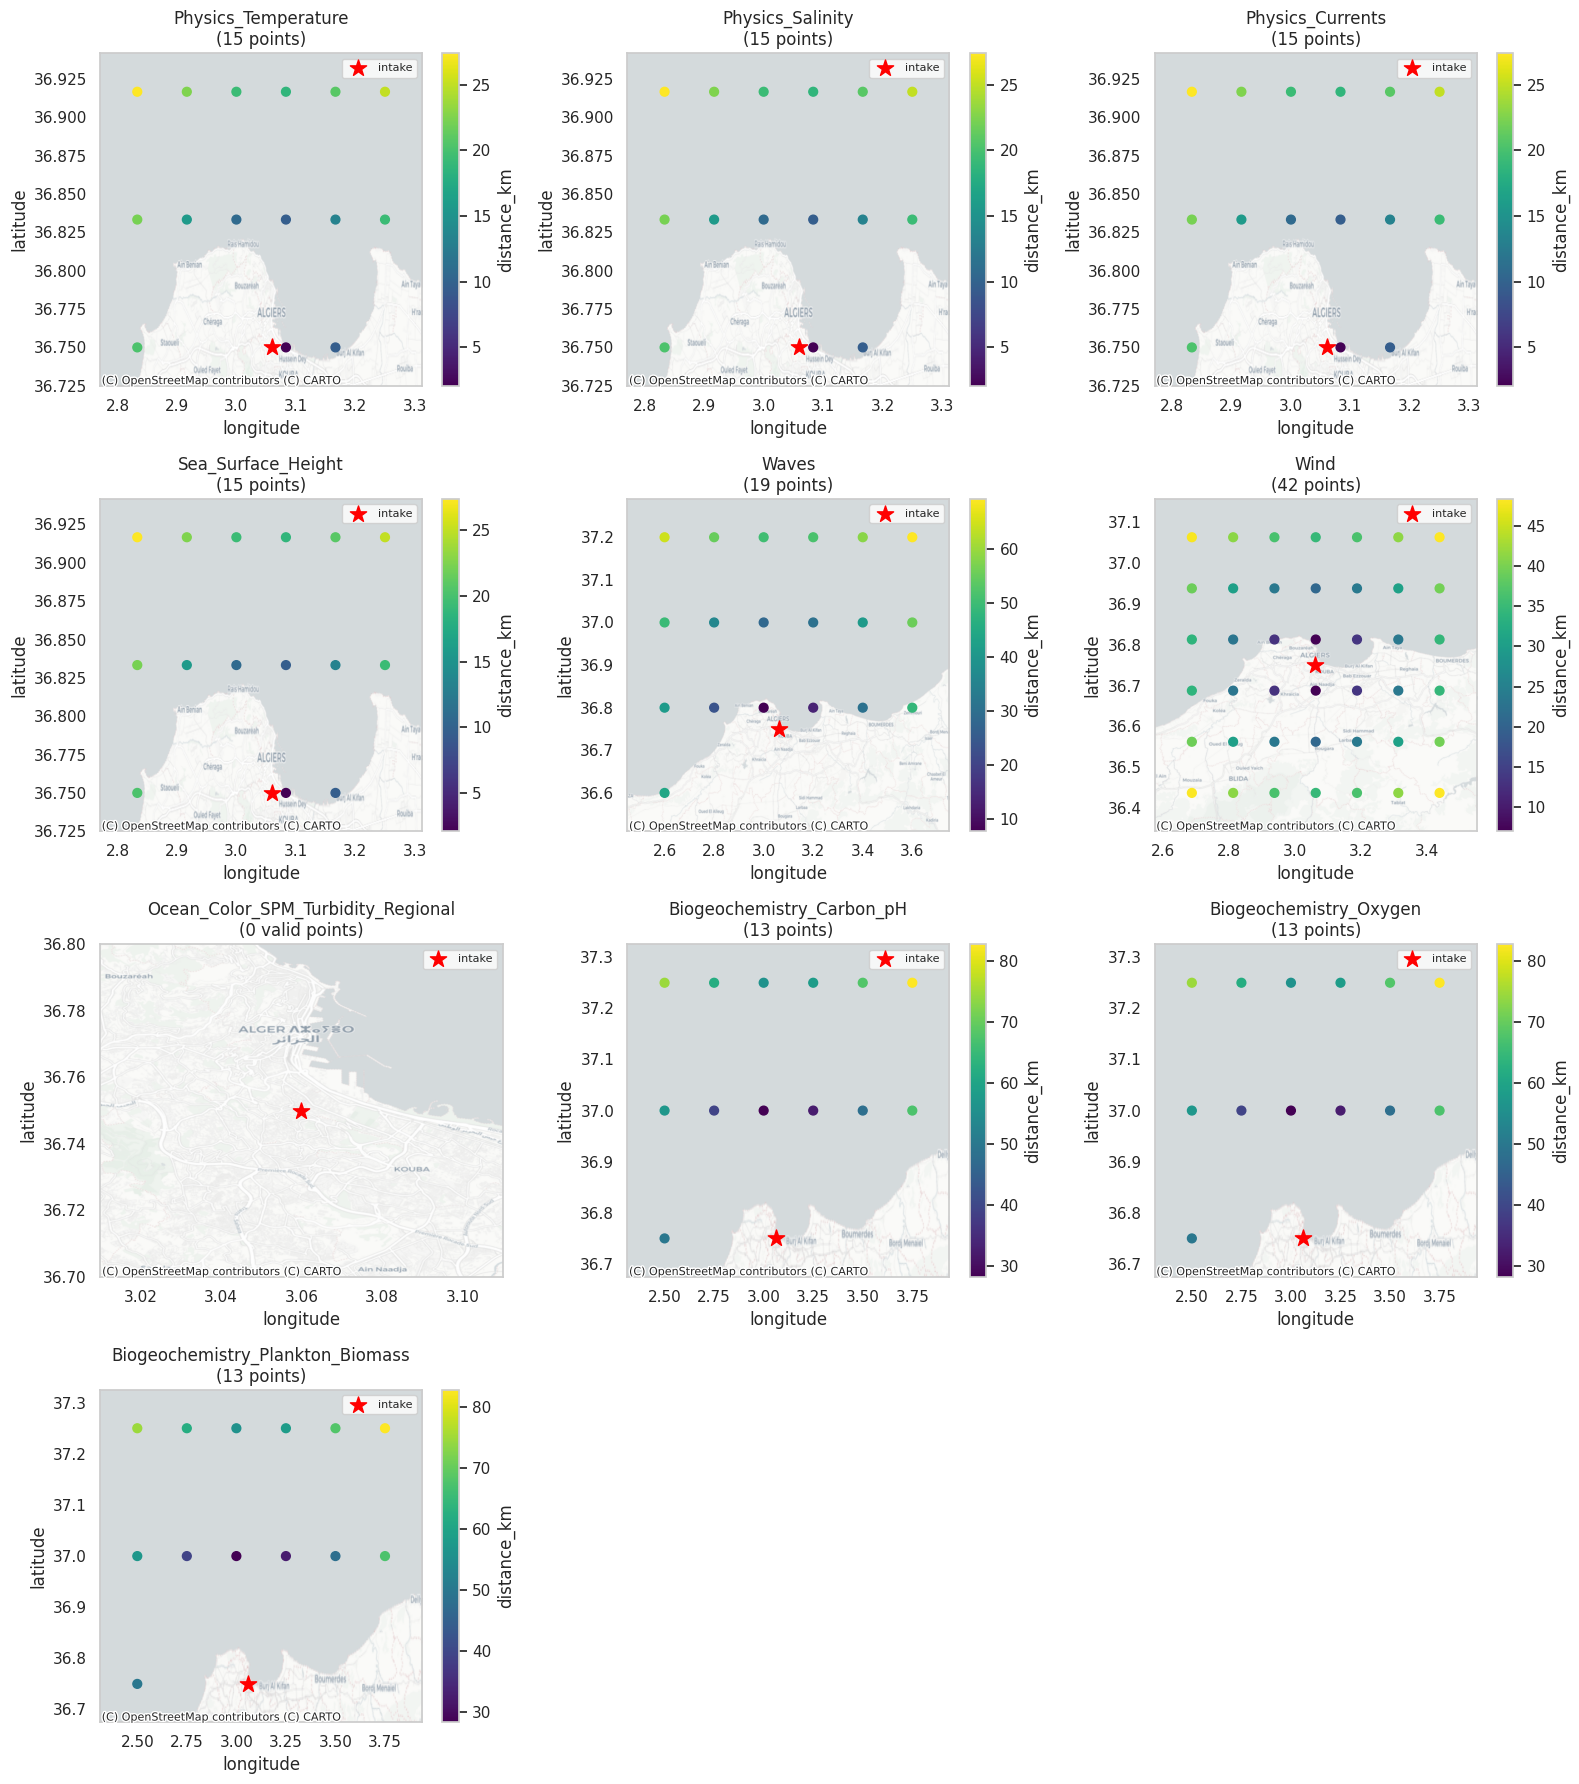

In [5]:
# where each product's grid points sit relative to the intake
n_products = len(raw_data)
n_cols = 3
n_rows = -(-n_products // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
axes = axes.ravel()
for ax, (name, df) in zip(axes, raw_data.items()):
    pts = grid_points(df)
    ax.scatter([INTAKE_LON], [INTAKE_LAT], c="red", marker="*", s=150, label="intake", zorder=2)
    if pts.empty:
        # all points for this product were dropped as land-masked / no-data (see Section 2 note above)
        pad = 0.05
        ax.set_xlim(INTAKE_LON - pad, INTAKE_LON + pad)
        ax.set_ylim(INTAKE_LAT - pad, INTAKE_LAT + pad)
        cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron, zorder=1)
        ax.set_title(f"{name}\n(0 valid points)")
        ax.set_xlabel("longitude")
        ax.set_ylabel("latitude")
        ax.legend(loc="upper right", fontsize=8)
        continue
    sc = ax.scatter(pts["longitude"], pts["latitude"], c=pts["distance_km"], cmap="viridis", s=40, zorder=2)
    # pad the view so the basemap isn't cropped tight to the points
    lon_pad = max((pts["longitude"].max() - pts["longitude"].min()) * 0.15, 0.02)
    lat_pad = max((pts["latitude"].max() - pts["latitude"].min()) * 0.15, 0.02)
    ax.set_xlim(min(pts["longitude"].min(), INTAKE_LON) - lon_pad, max(pts["longitude"].max(), INTAKE_LON) + lon_pad)
    ax.set_ylim(min(pts["latitude"].min(), INTAKE_LAT) - lat_pad, max(pts["latitude"].max(), INTAKE_LAT) + lat_pad)
    cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron, zorder=1)
    ax.set_title(f"{name}\n({len(pts)} points)")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.legend(loc="upper right", fontsize=8)
    fig.colorbar(sc, ax=ax, label="distance_km")
for ax in axes[n_products:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
# number of valid (non-null) values contributed by each grid point, per product's primary variable
for name, df in raw_data.items():
    var = PRODUCTS[name]["vars"][0]
    pts = (
        df.groupby(["latitude", "longitude"], as_index=False)
        .agg(distance_km=("distance_km", "first"), n_valid=(var, "count"), n_total=(var, "size"))
        .sort_values("distance_km")
    )
    print(f"\n{name} — non-null '{var}' records per grid point:")
    print(pts.to_string(index=False))


Physics_Temperature — non-null 'thetao' records per grid point:
 latitude  longitude  distance_km  n_valid  n_total
36.750000   3.083343     2.079802     1576     1576
36.833336   3.083343     9.496748     1576     1576
36.750000   3.166672     9.503947     1576     1576
36.833336   3.000000    10.696399     1576     1576
36.833336   3.166672    13.270049     1576     1576
36.833336   2.916672    15.772125     1576     1576
36.916670   3.083343    18.648990     1576     1576
36.916670   3.000000    19.286865     1576     1576
36.833336   3.250000    19.290330     1576     1576
36.750000   2.833343    20.194040     1576     1576
36.916670   3.166672    20.822998     1576     1576
36.833336   2.833343    22.208634     1576     1576
36.916670   2.916672    22.498529     1576     1576
36.916670   3.250000    25.087972     1576     1576
36.916670   2.833343    27.393083     1576     1576

Physics_Salinity — non-null 'so' records per grid point:
 latitude  longitude  distance_km  n_valid  n

## 3. Data quality / missingness audit

In [7]:
# overall non-null % per variable, across all grid points and days
missing_rows = []
for name, df in raw_data.items():
    for var in PRODUCTS[name]["vars"]:
        missing_rows.append({"product": name, "variable": var, "non_null_pct": 100 * df[var].notna().mean()})
missing_summary = pd.DataFrame(missing_rows).sort_values("non_null_pct").reset_index(drop=True)
missing_summary

,product,variable,non_null_pct
0,Physics_Temperature,thetao,100.0
1,Physics_Salinity,so,100.0
2,Physics_Currents,uo,100.0
3,Physics_Currents,vo,100.0
4,Sea_Surface_Height,zos,100.0
5,Waves,VHM0,100.0
6,Wind,eastward_wind,100.0
7,Wind,northward_wind,100.0
8,Biogeochemistry_Carbon_pH,ph,100.0
9,Biogeochemistry_Carbon_pH,dissic,100.0


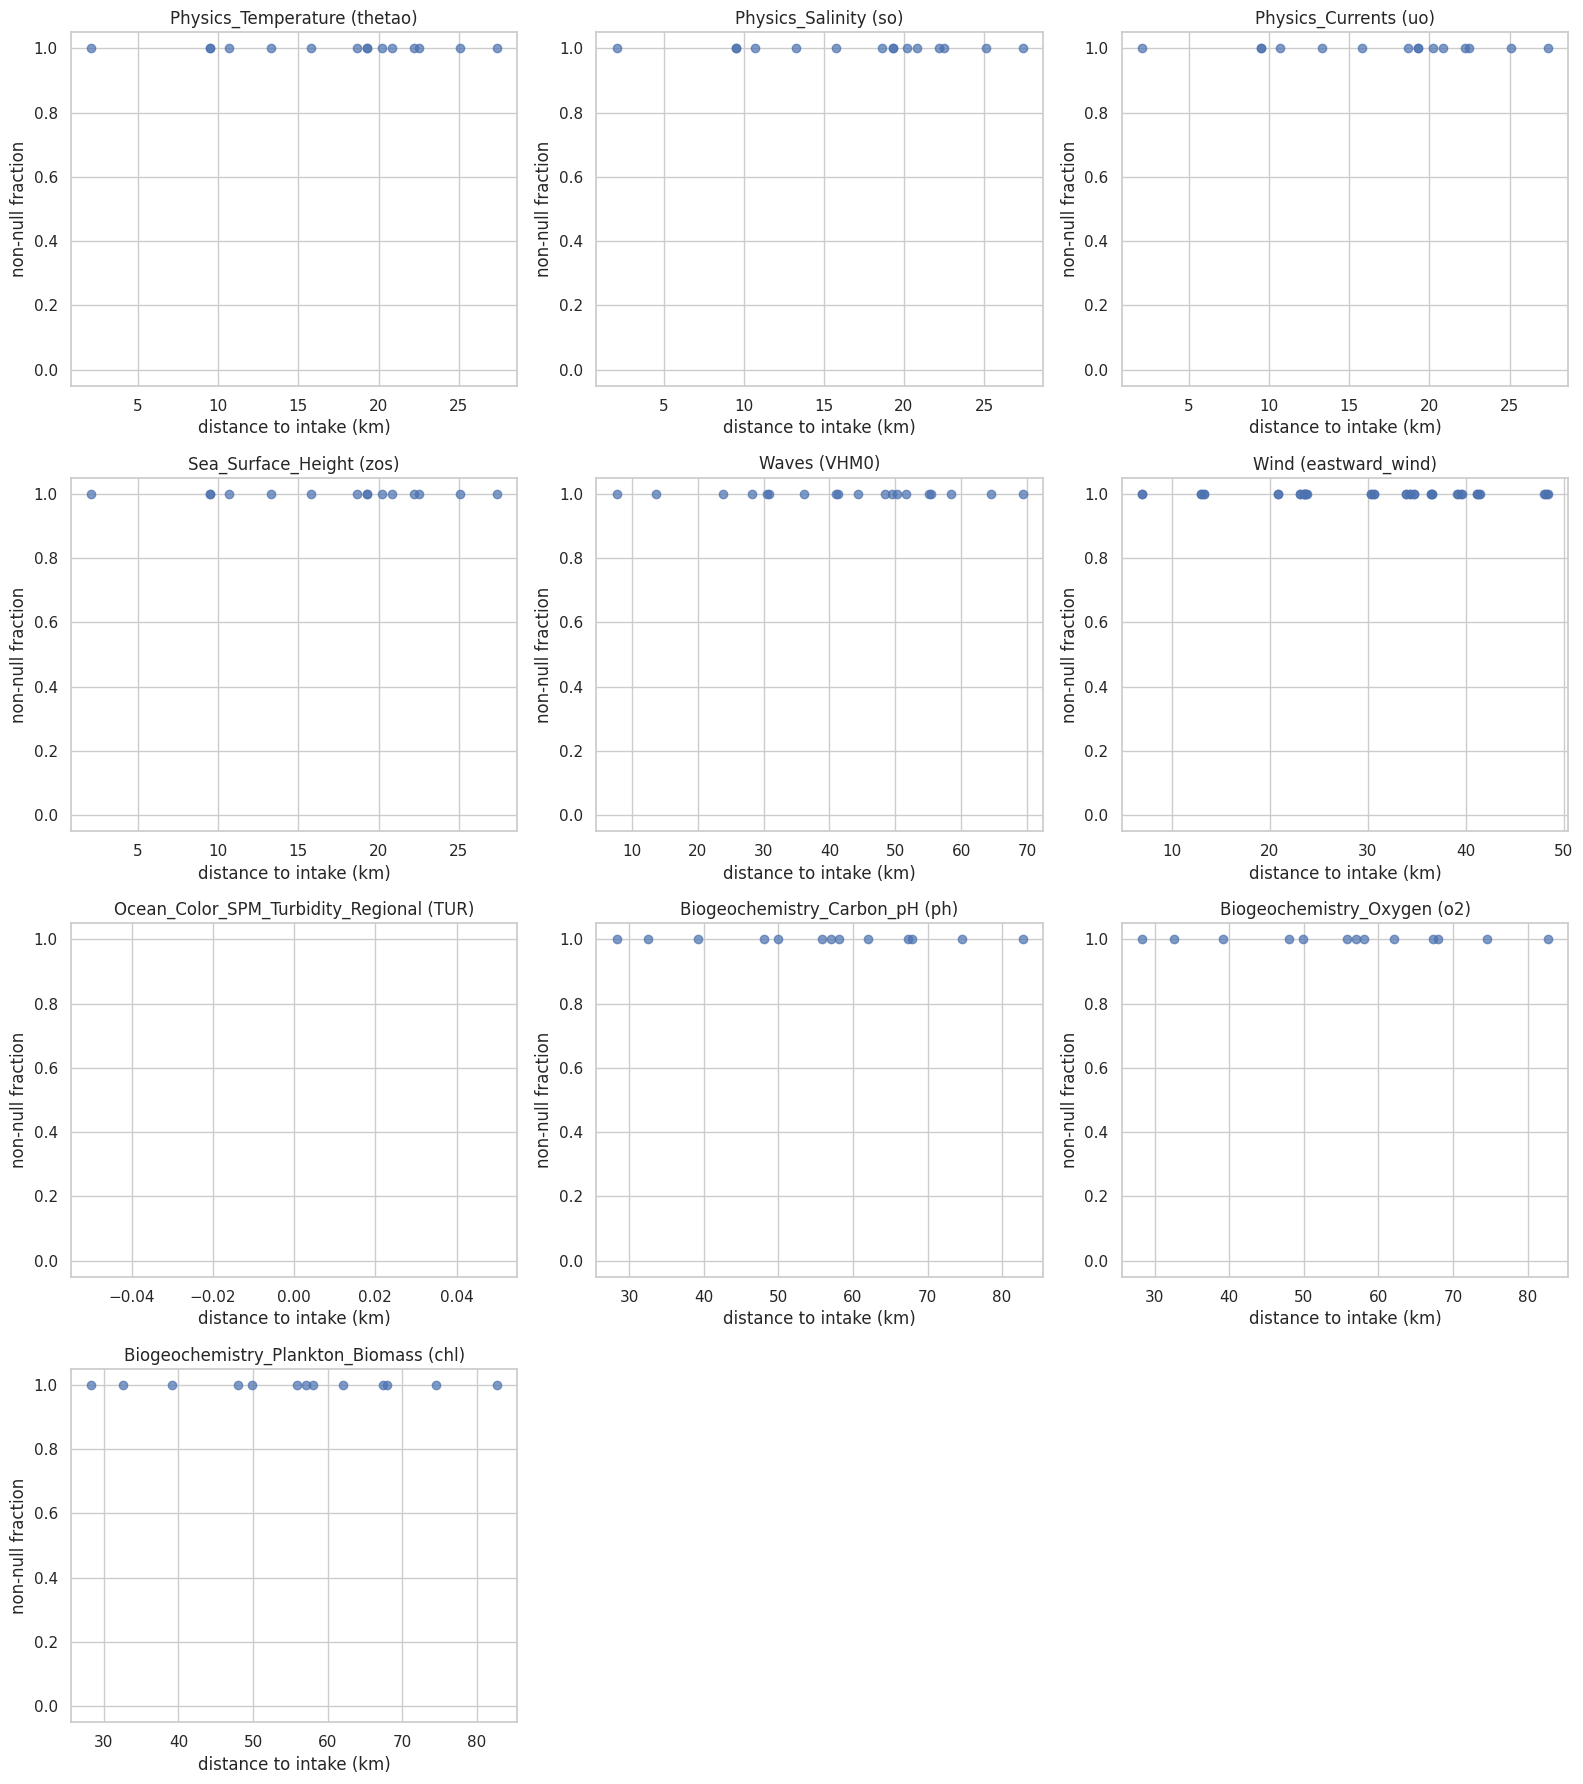

In [8]:
# is missingness explained by distance from the intake (land-masked cells), or scattered across the grid regardless of distance?
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
axes = axes.ravel()
for ax, (name, df) in zip(axes, raw_data.items()):
    var = PRODUCTS[name]["vars"][0]
    pts = df.groupby(["latitude", "longitude"], as_index=False).agg(
        distance_km=("distance_km", "first"), non_null_frac=(var, lambda s: s.notna().mean())
    )
    ax.scatter(pts["distance_km"], pts["non_null_frac"], alpha=0.7)
    ax.set_title(f"{name} ({var})")
    ax.set_xlabel("distance to intake (km)")
    ax.set_ylabel("non-null fraction")
    ax.set_ylim(-0.05, 1.05)
for ax in axes[n_products:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [9]:
# date coverage: does every product cover the full Feb2024-Feb2025 span with no missing days?
# (bounds come from non-empty products only - a product with 0 land-filtered points has no dates at all)
non_empty_data = {name: df for name, df in raw_data.items() if not df.empty}
full_range = pd.date_range(
    min(df["day"].min() for df in non_empty_data.values()),
    max(df["day"].max() for df in non_empty_data.values()),
    freq="D",
)
coverage = pd.DataFrame(
    {
        "n_unique_days": {name: df["day"].nunique() for name, df in raw_data.items()},
        "expected_days": len(full_range),
        "missing_days": {name: len(full_range) - df["day"].nunique() for name, df in raw_data.items()},
    }
)
coverage

,n_unique_days,expected_days,missing_days
Physics_Temperature,394,394,0
Physics_Salinity,394,394,0
Physics_Currents,394,394,0
Sea_Surface_Height,394,394,0
Waves,394,394,0
Wind,394,394,0
Ocean_Color_SPM_Turbidity_Regional,0,394,394
Biogeochemistry_Carbon_pH,394,394,0
Biogeochemistry_Oxygen,394,394,0
Biogeochemistry_Plankton_Biomass,394,394,0


## 4. Spatiotemporal exploration

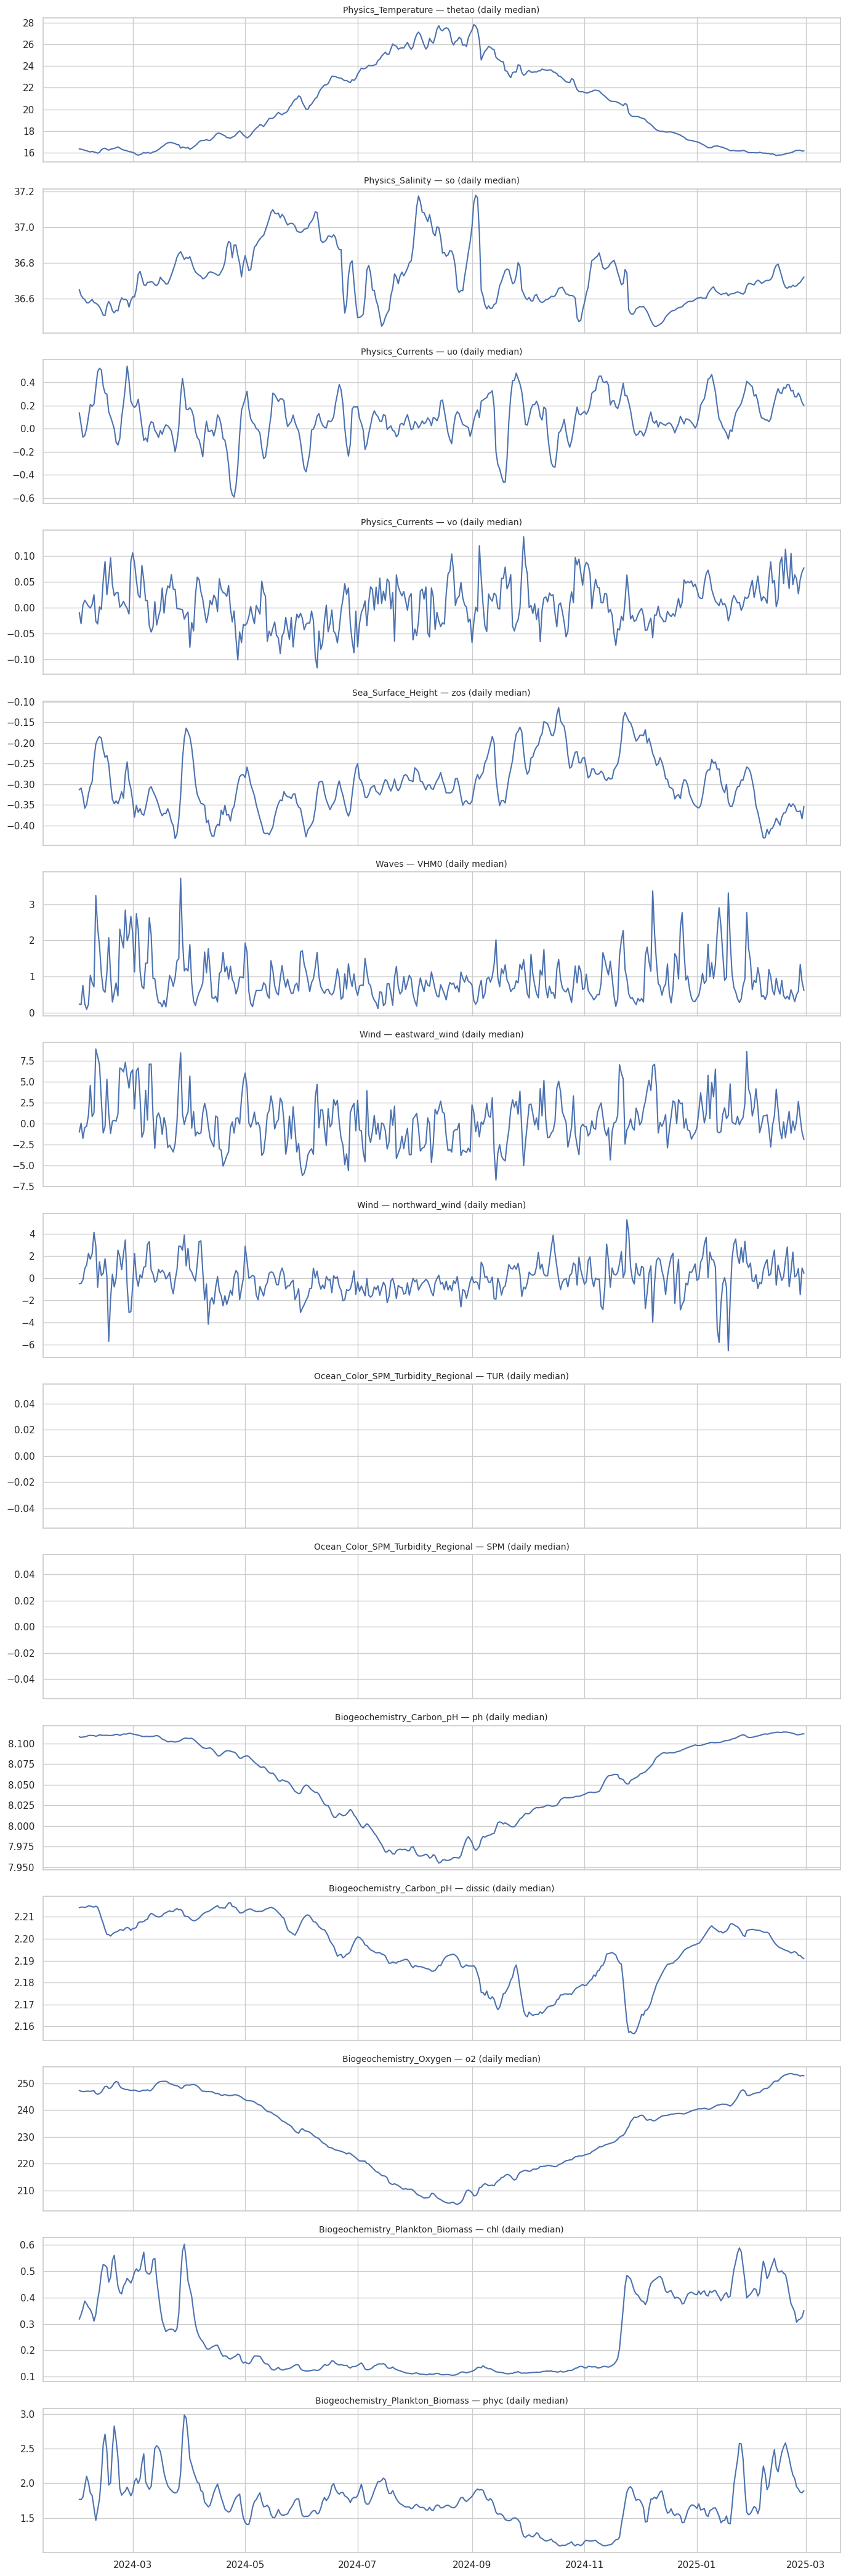

In [10]:
def daily_median(df, var):
    return df.groupby("day")[var].median()


# daily median (across matched grid points) time series, one panel per variable
n_vars = len(missing_summary)
fig, axes = plt.subplots(n_vars, 1, figsize=(14, 2.8 * n_vars), sharex=True)
i = 0
for name, df in raw_data.items():
    for var in PRODUCTS[name]["vars"]:
        s = daily_median(df, var)
        axes[i].plot(s.index, s.values)
        axes[i].set_title(f"{name} — {var} (daily median)", fontsize=10)
        i += 1
plt.tight_layout()
plt.show()

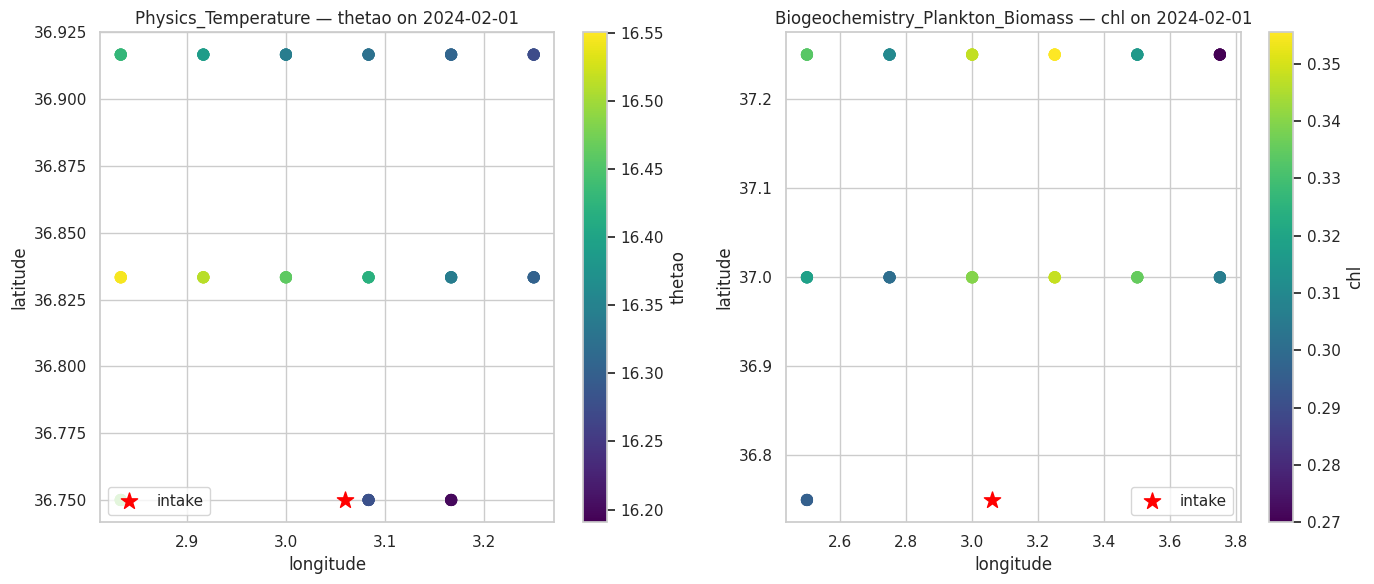

In [11]:
# spatial snapshot: value across the grid points on a single sample date
sample_date = raw_data["Physics_Temperature"].loc[raw_data["Physics_Temperature"]["thetao"].notna(), "day"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, var) in zip(axes, [("Physics_Temperature", "thetao"), ("Biogeochemistry_Plankton_Biomass", "chl")]):
    df = raw_data[name]
    snap = df[df["day"] == sample_date]
    sc = ax.scatter(snap["longitude"], snap["latitude"], c=snap[var], cmap="viridis", s=60)
    ax.scatter([INTAKE_LON], [INTAKE_LAT], c="red", marker="*", s=150, label="intake")
    ax.set_title(f"{name} — {var} on {sample_date.date()}")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.legend()
    fig.colorbar(sc, ax=ax, label=var)
plt.tight_layout()
plt.show()

## 5. Temporal structure — autocorrelation & decomposition

Using each variable's daily median series (~395 days, matching the grid-point aggregation approach used for the cleaned data). ACF/PACF go out to 30 lags to look for synoptic/monthly structure; decomposition uses a 7-day period to isolate a weekly cycle from trend and residual. Series with too few non-null daily values (e.g. TUR/SPM, which have none) are skipped.

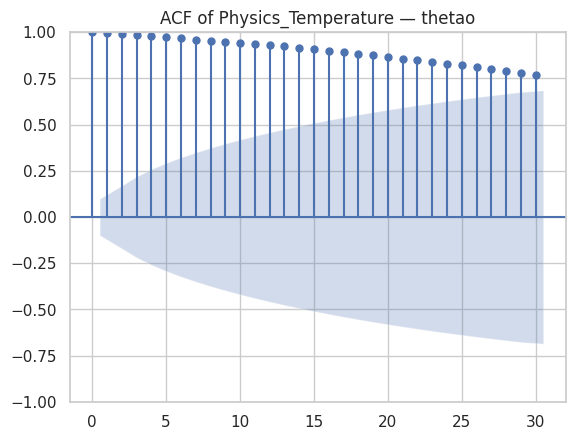

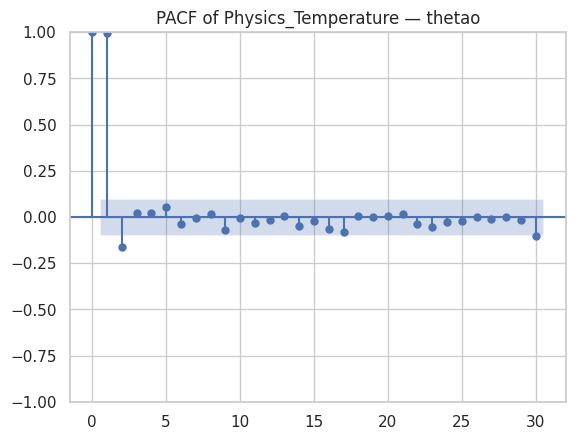

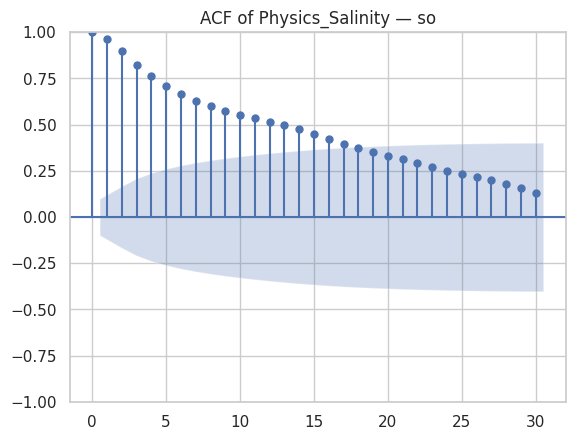

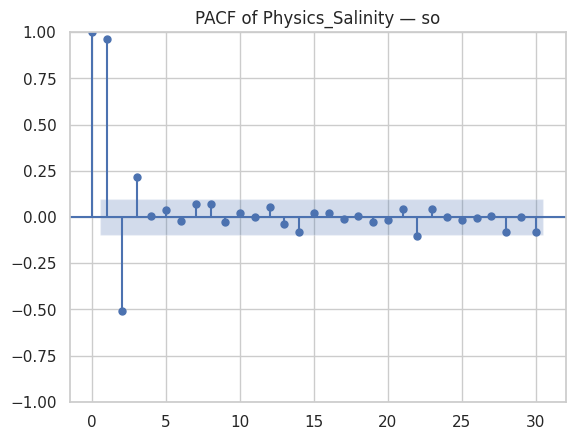

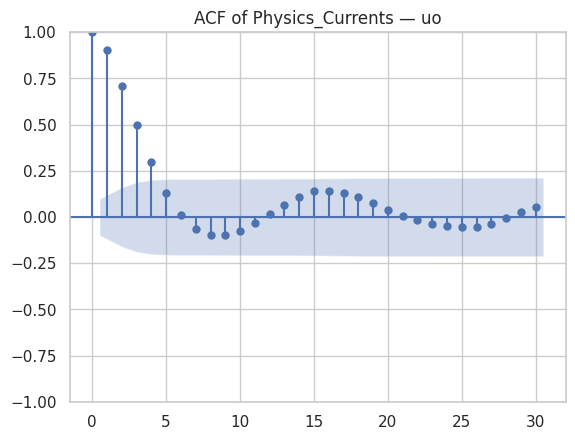

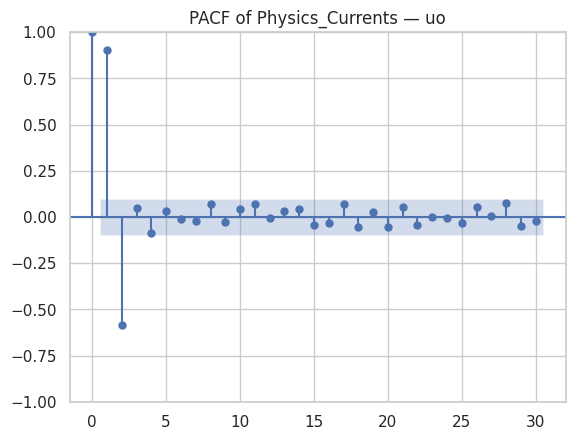

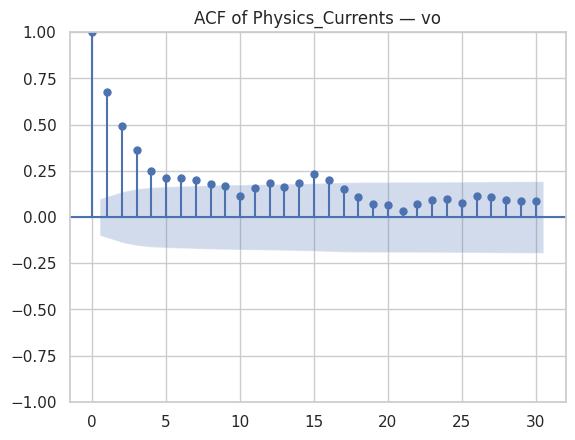

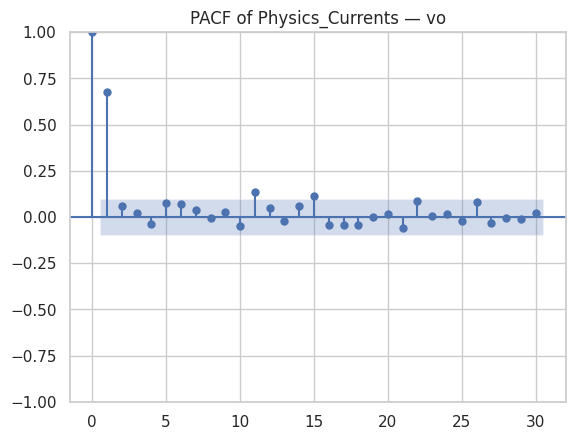

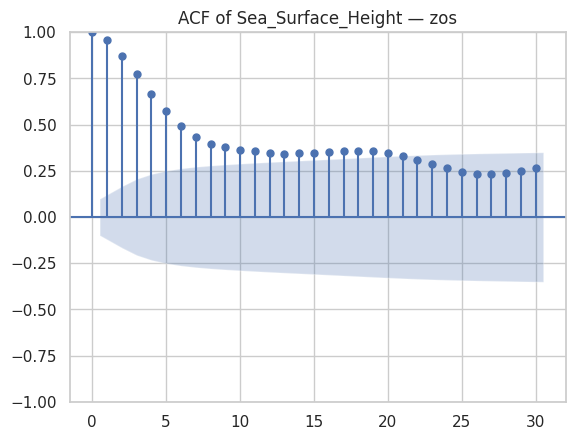

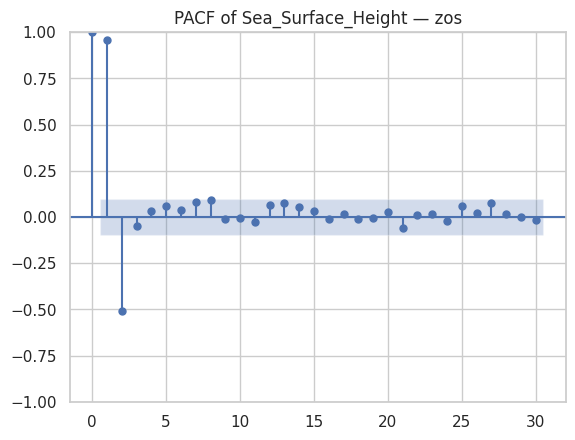

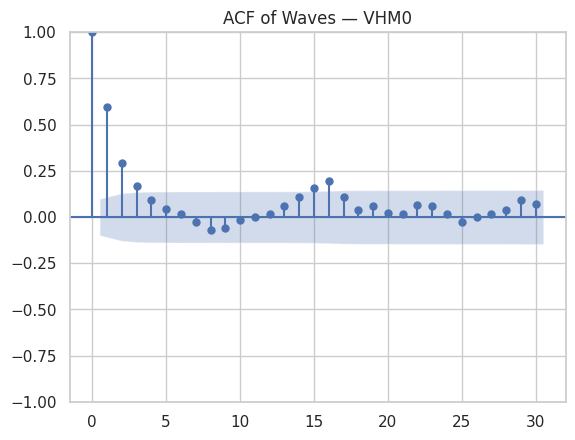

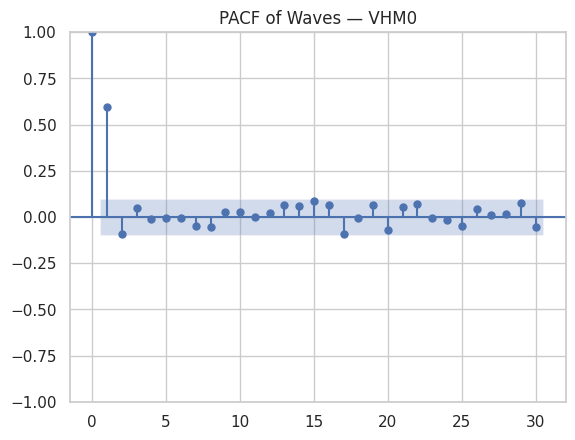

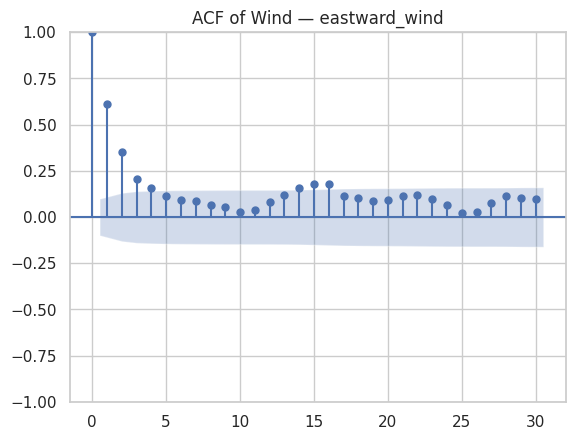

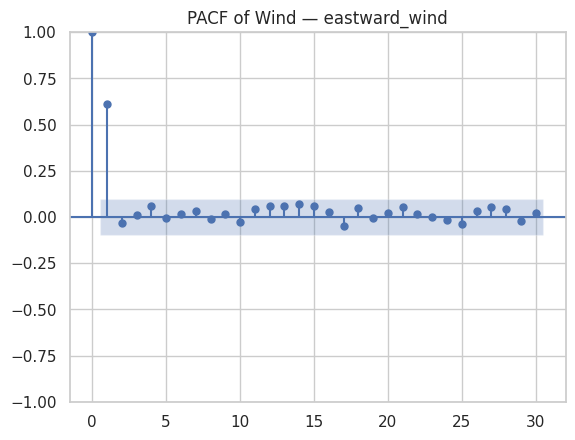

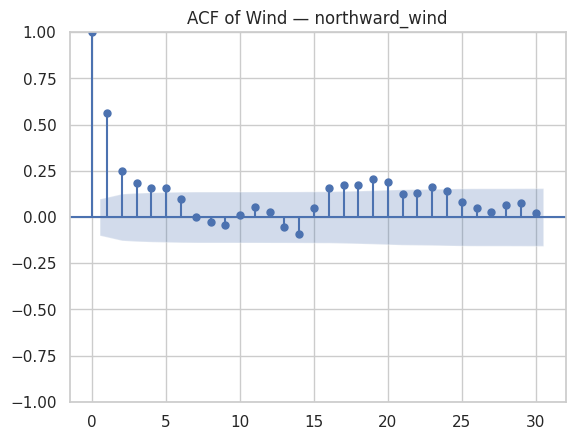

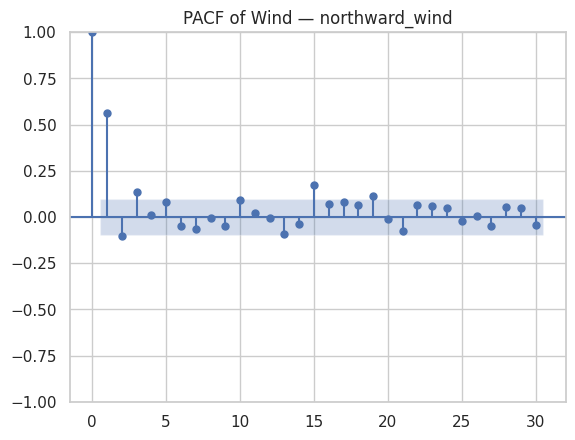

Skipping Ocean_Color_SPM_Turbidity_Regional — TUR: not enough non-null daily values (0)
Skipping Ocean_Color_SPM_Turbidity_Regional — SPM: not enough non-null daily values (0)


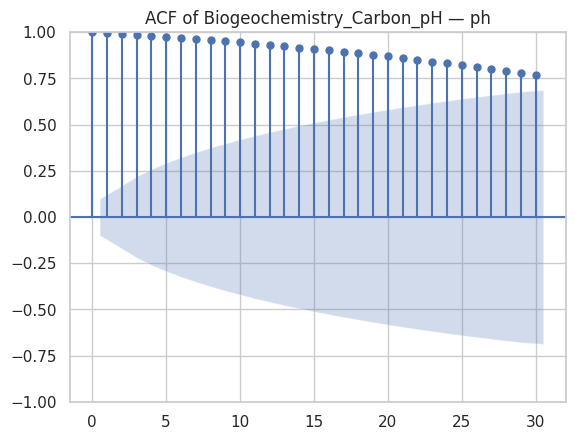

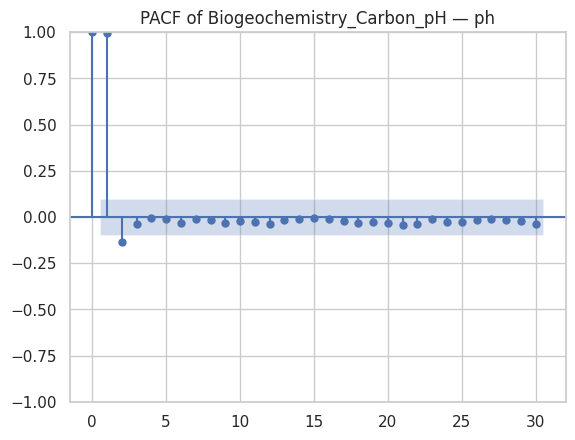

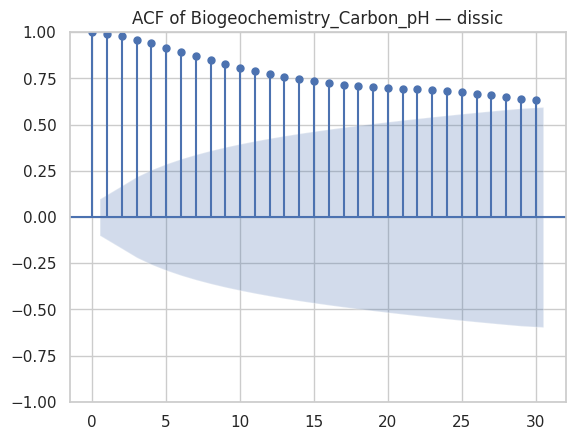

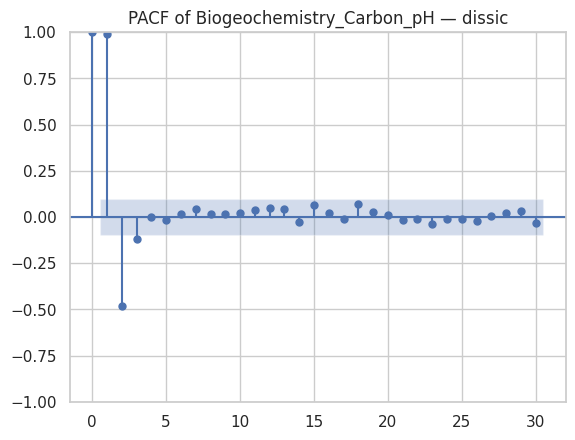

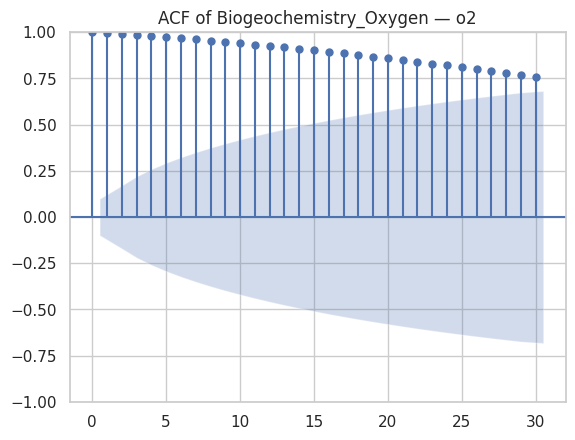

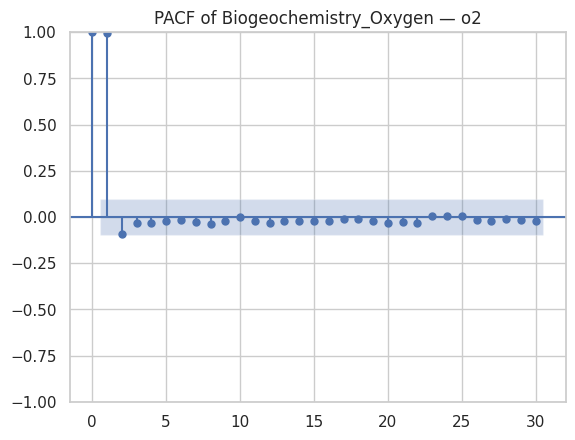

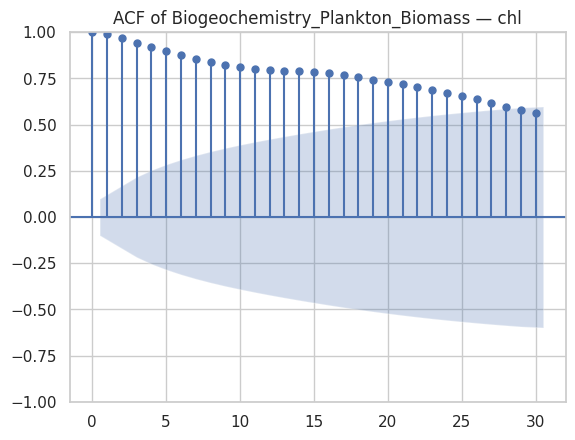

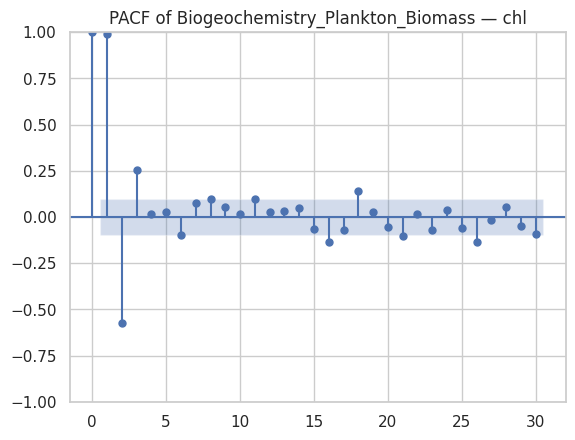

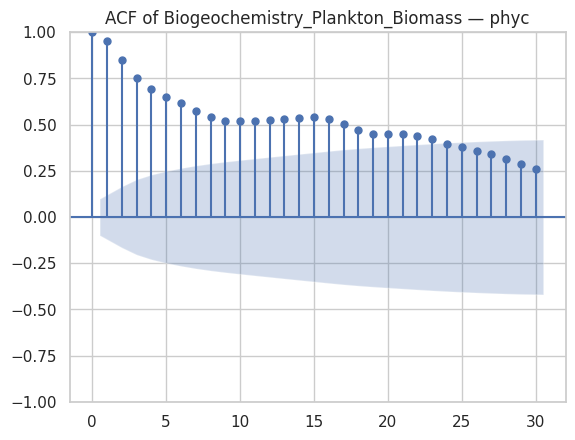

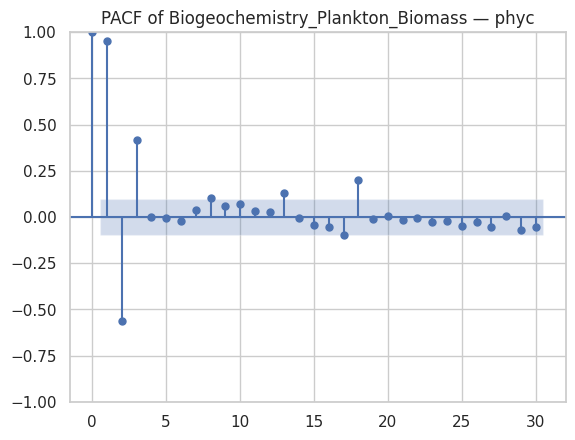

In [12]:
# ACF and PACF for each variable's daily median series
for name, df in raw_data.items():
    for var in PRODUCTS[name]["vars"]:
        series = daily_median(df, var).dropna()
        if len(series) < 20:
            print(f"Skipping {name} — {var}: not enough non-null daily values ({len(series)})")
            continue
        plot_acf(series, lags=30)
        plt.title(f"ACF of {name} — {var}")
        plt.show()

        plot_pacf(series, lags=30)
        plt.title(f"PACF of {name} — {var}")
        plt.show()

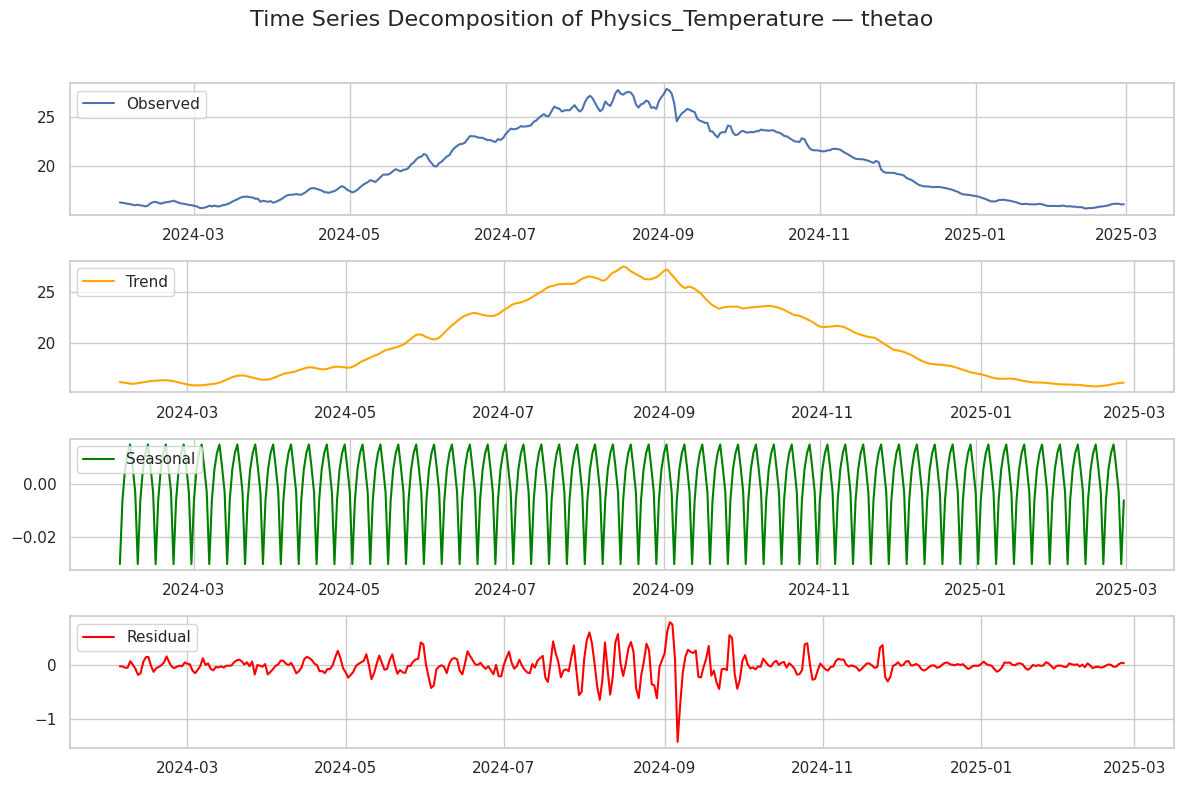

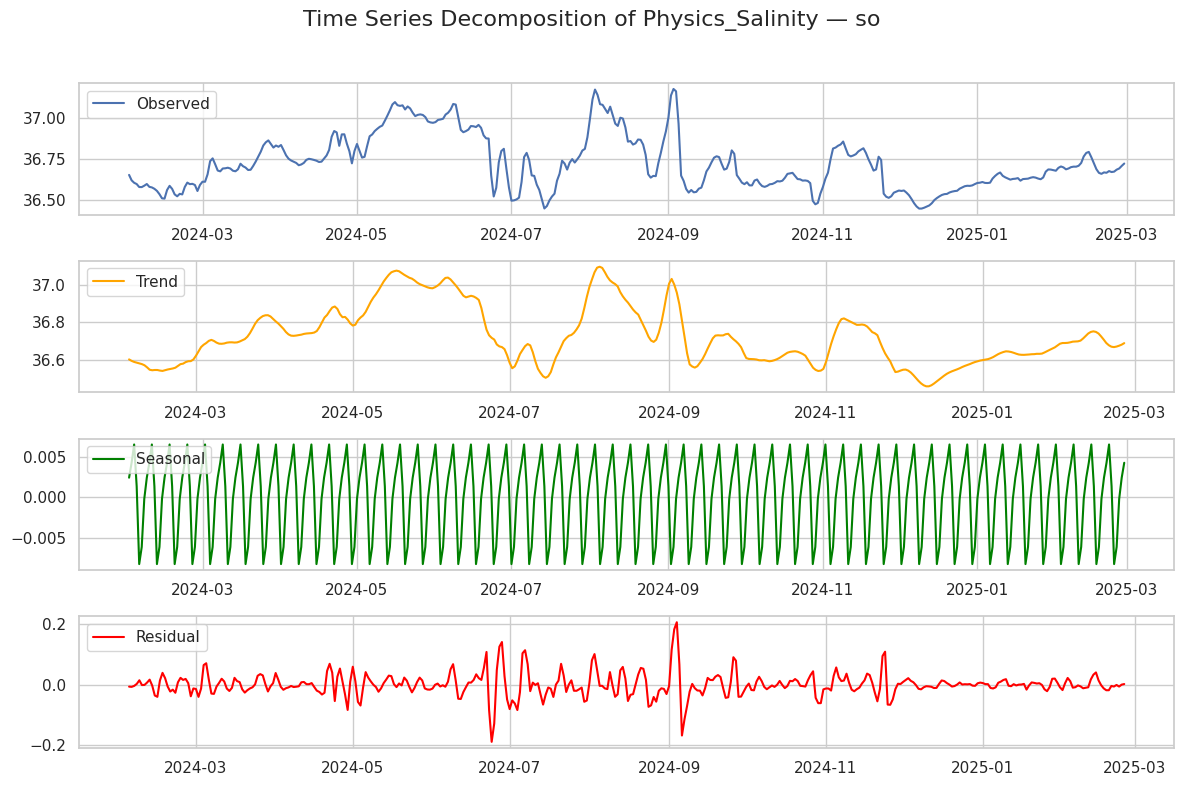

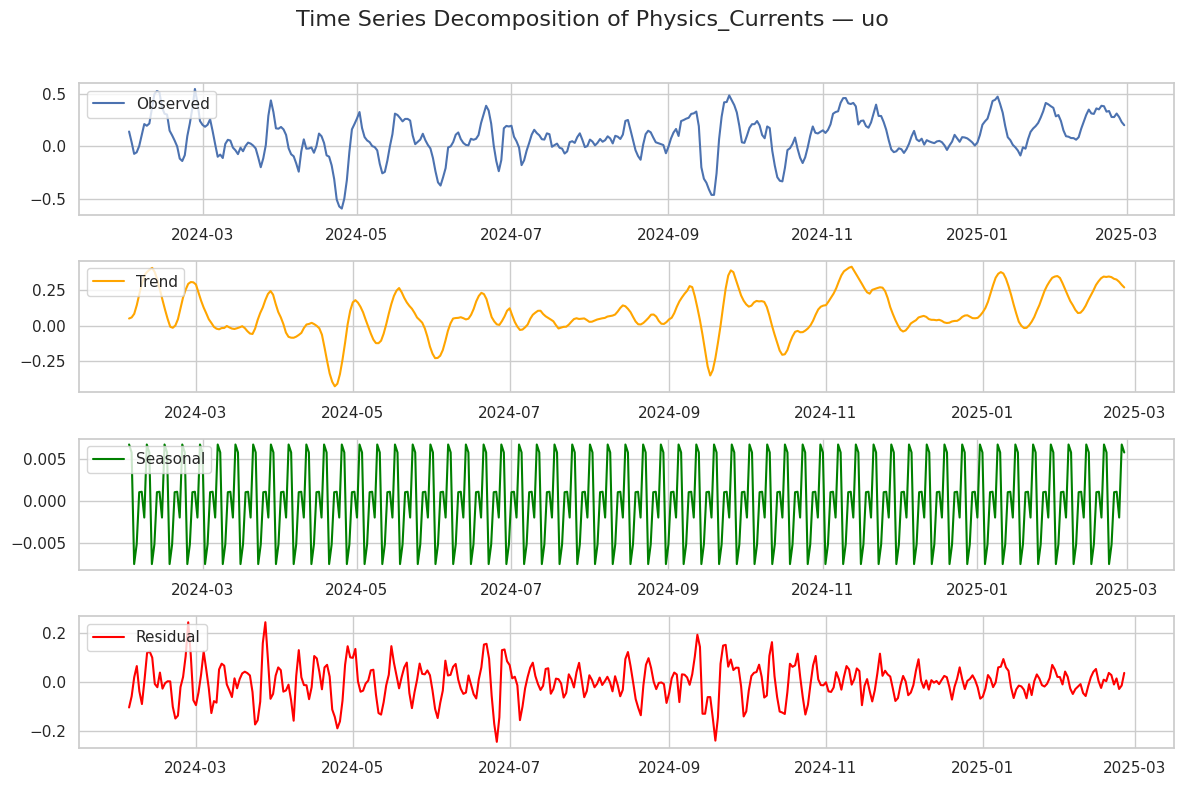

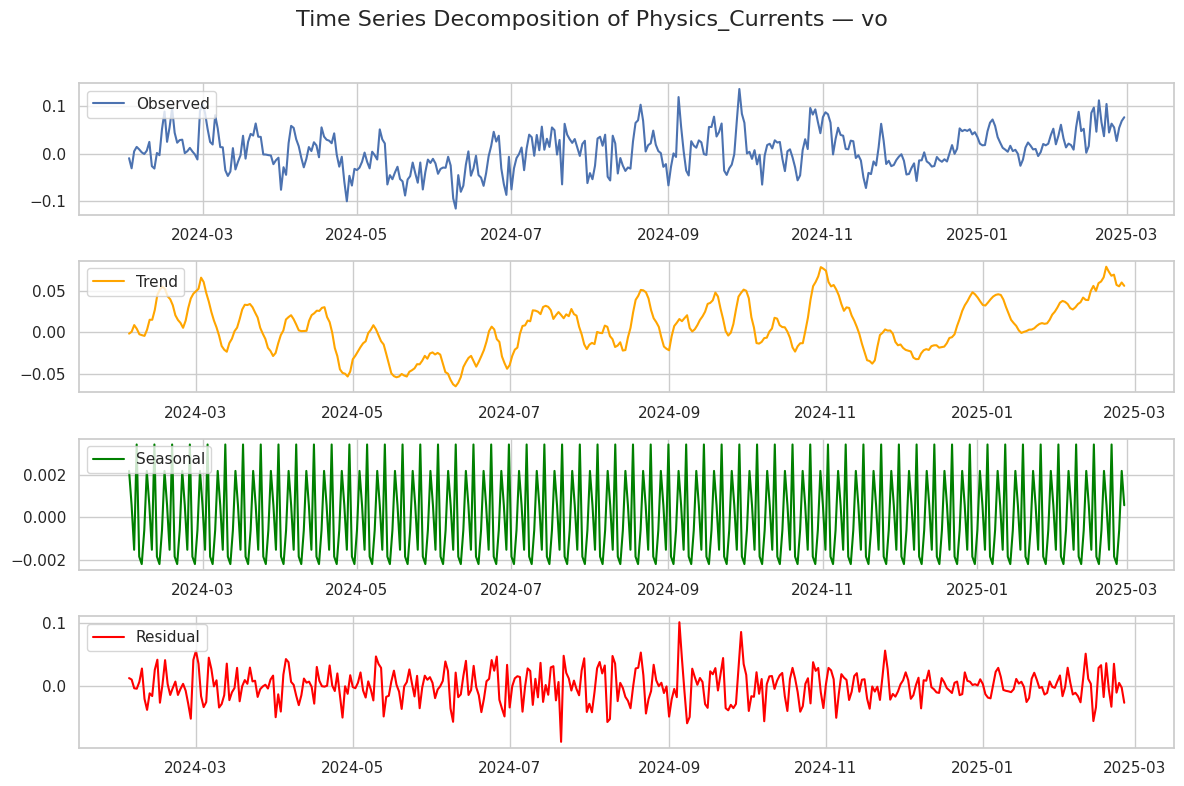

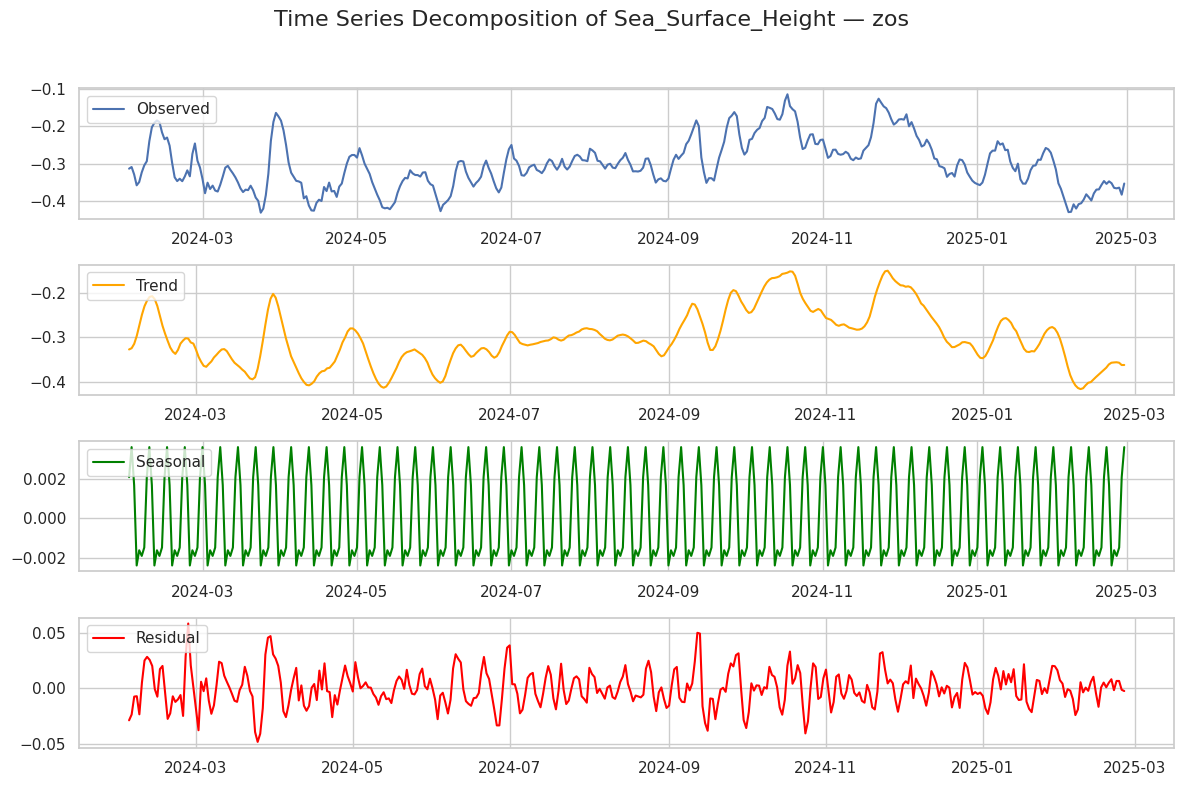

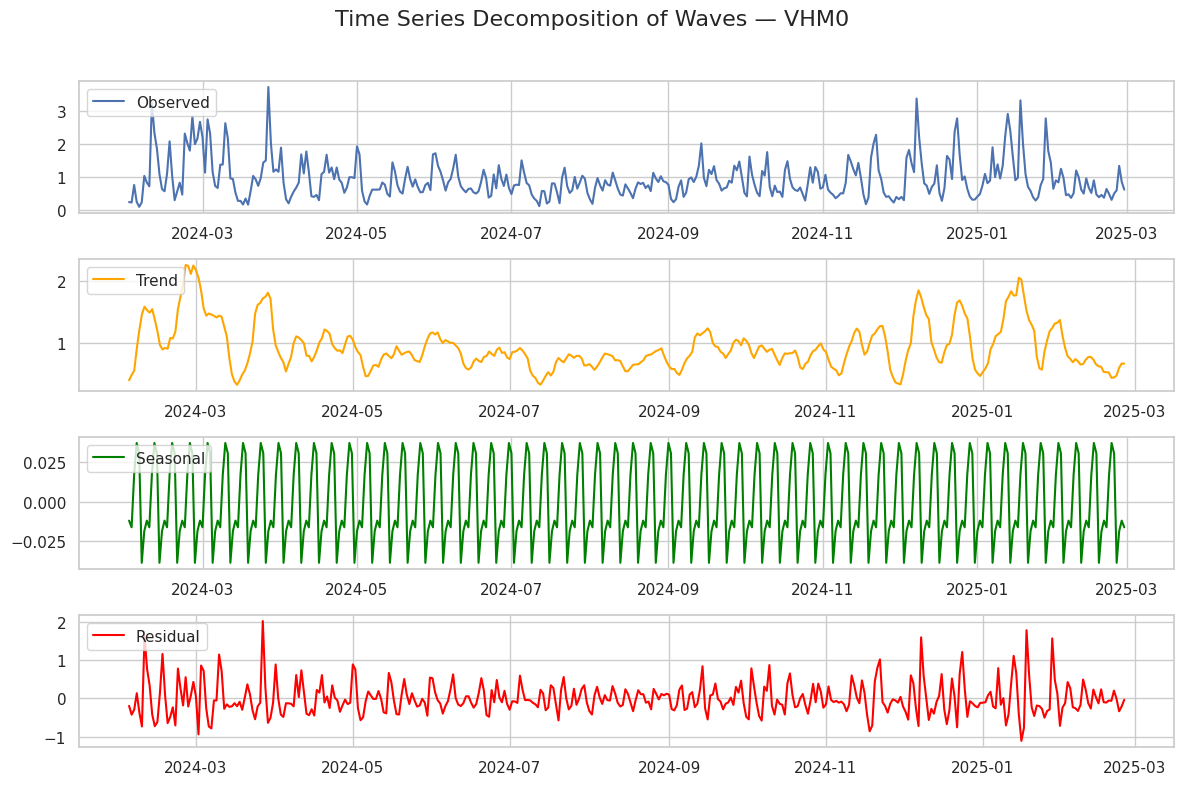

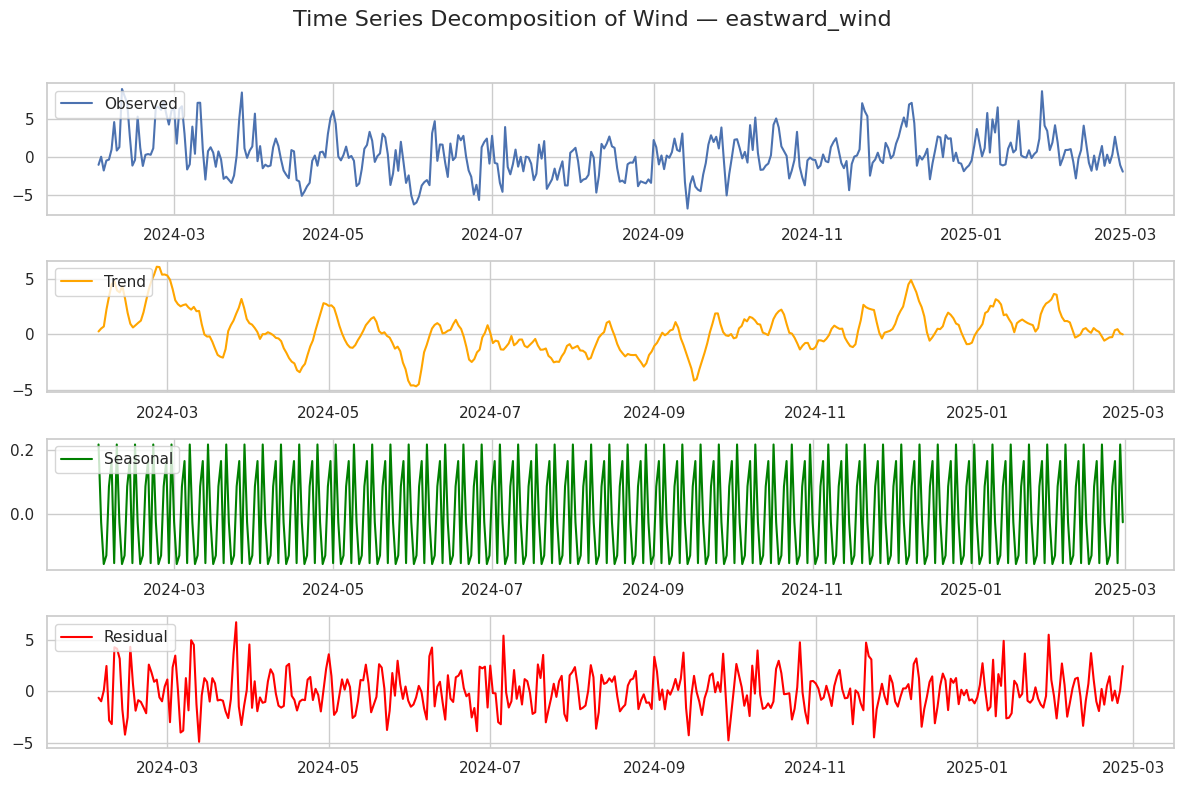

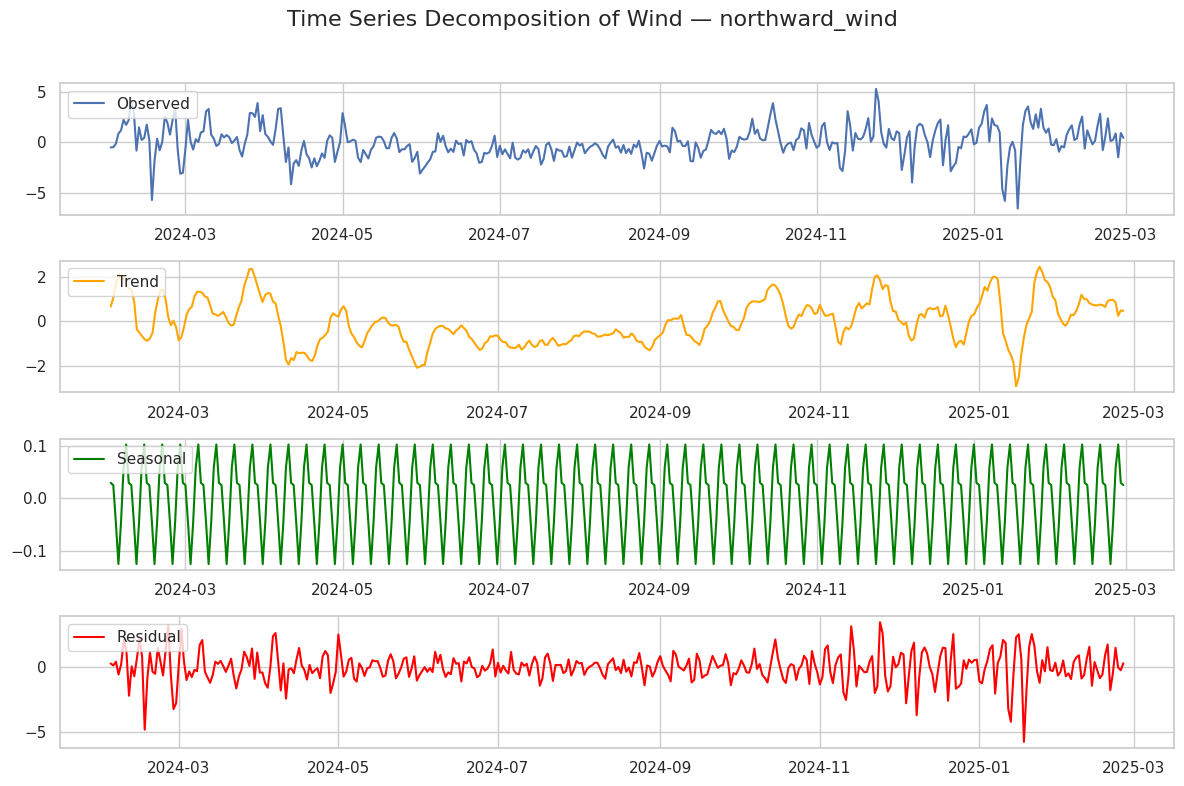

Skipping Ocean_Color_SPM_Turbidity_Regional — TUR: not enough non-null daily values (0)
Skipping Ocean_Color_SPM_Turbidity_Regional — SPM: not enough non-null daily values (0)


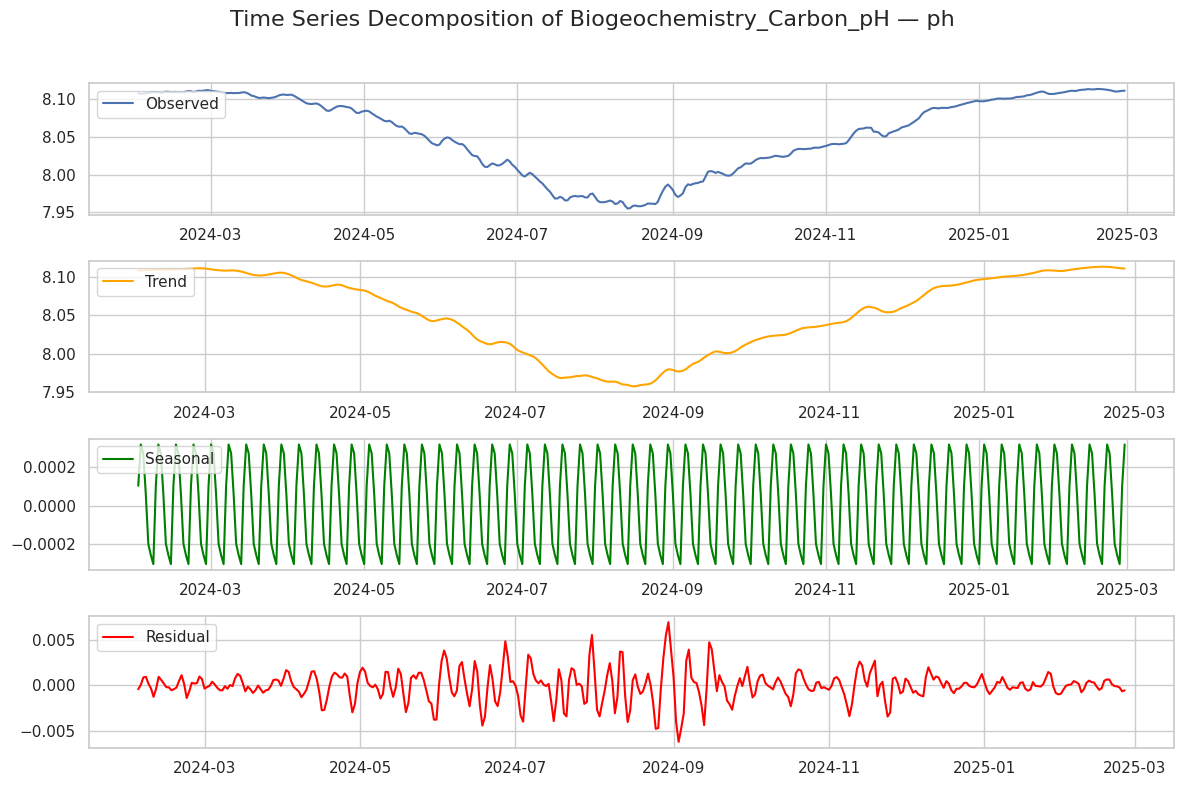

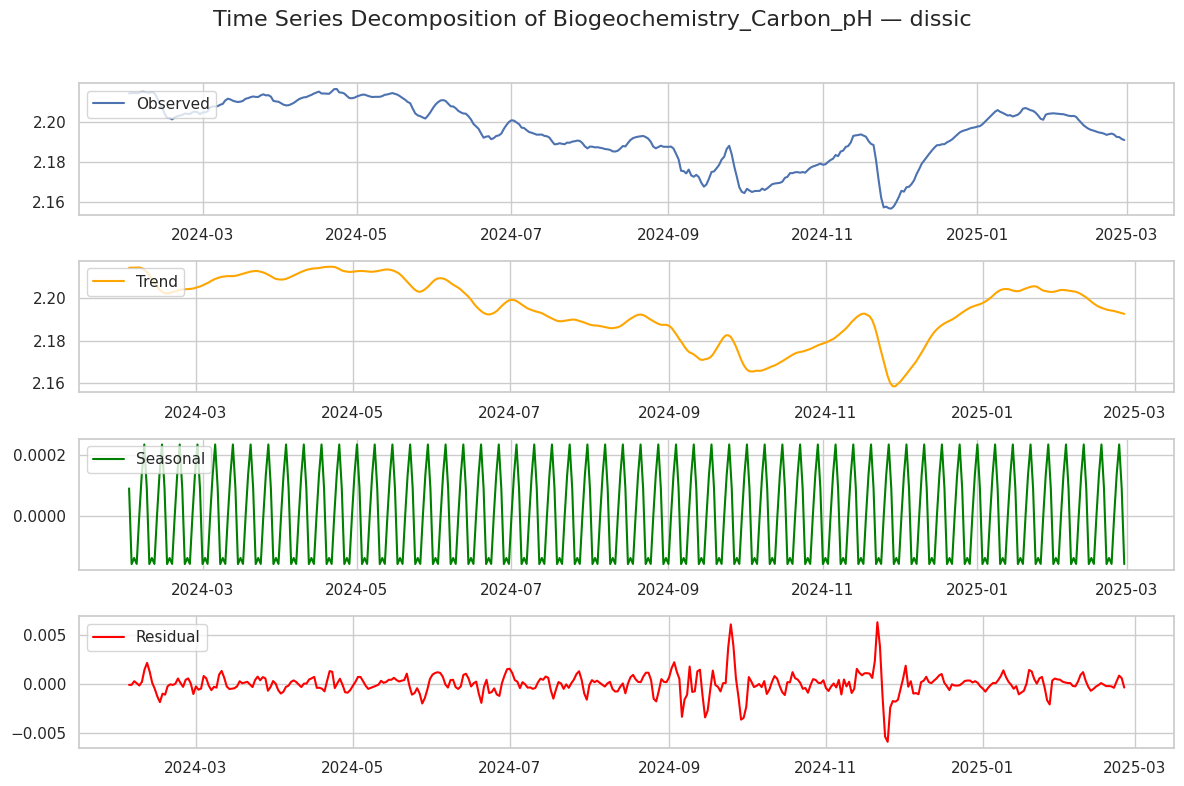

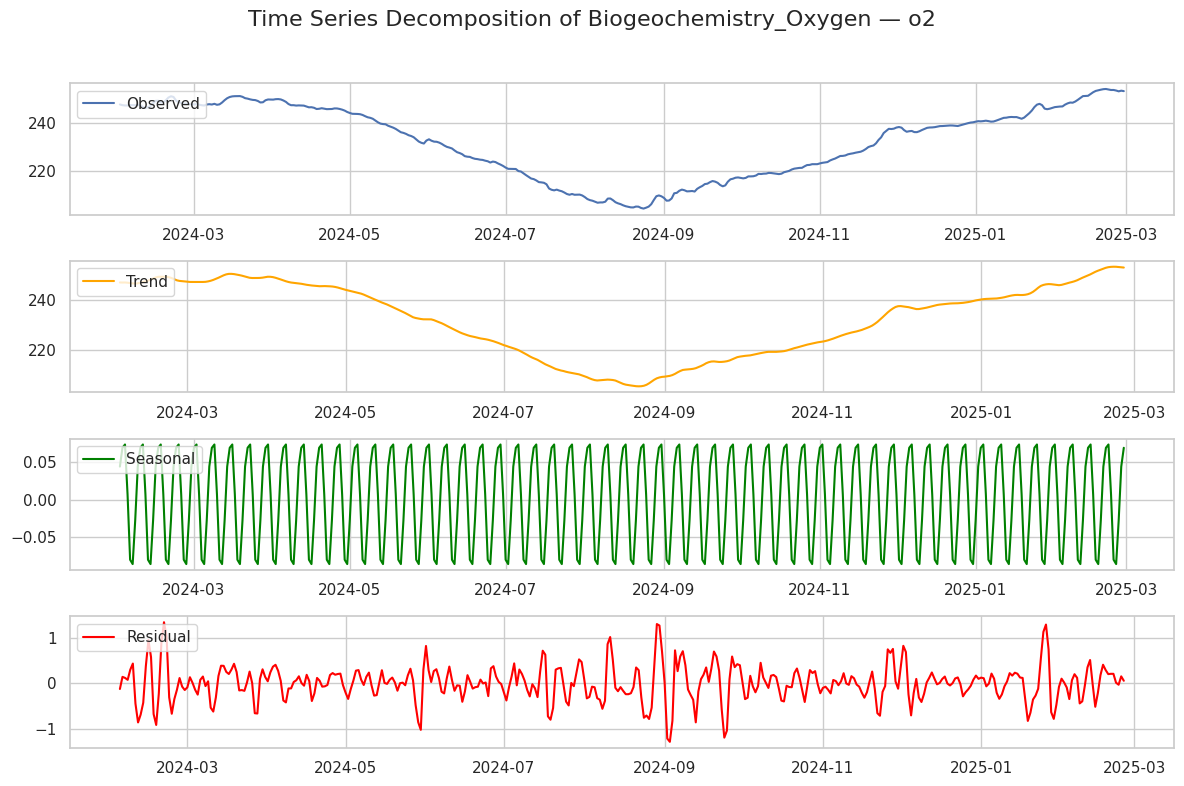

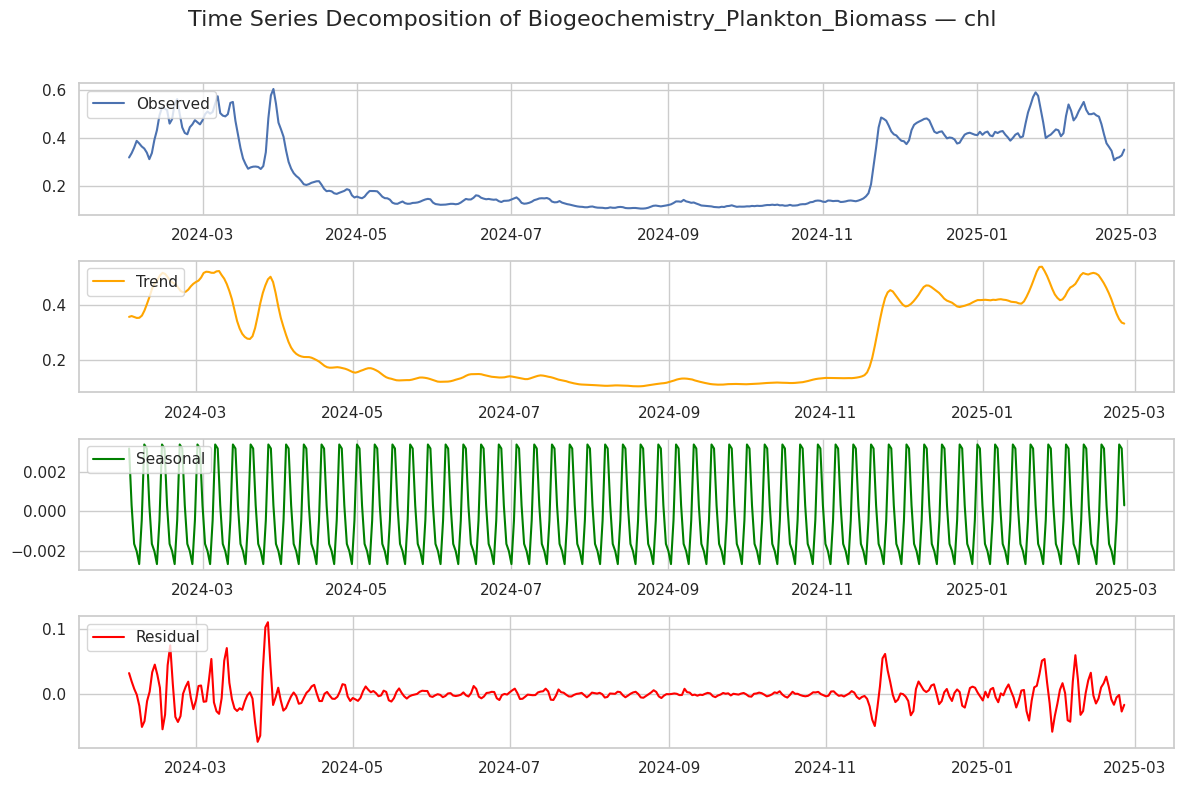

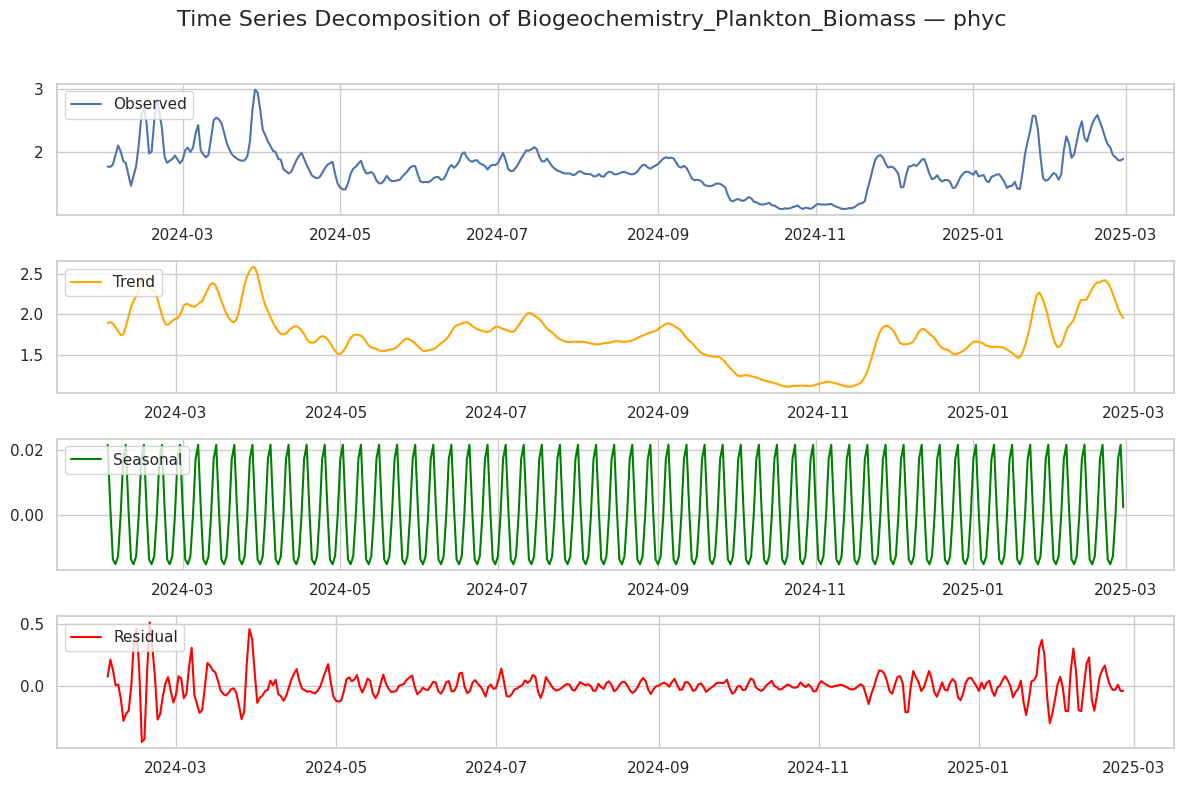

In [13]:
# seasonal decomposition (weekly period) for each variable's daily median series
for name, df in raw_data.items():
    for var in PRODUCTS[name]["vars"]:
        series = daily_median(df, var).dropna()
        if len(series) < 14:
            print(f"Skipping {name} — {var}: not enough non-null daily values ({len(series)})")
            continue
        decomp = seasonal_decompose(series, model="additive", period=7)
        plt.figure(figsize=(12, 8))
        plt.suptitle(f"Time Series Decomposition of {name} — {var}", fontsize=16)
        plt.subplot(411)
        plt.plot(decomp.observed, label="Observed")
        plt.legend(loc="upper left")
        plt.subplot(412)
        plt.plot(decomp.trend, label="Trend", color="orange")
        plt.legend(loc="upper left")
        plt.subplot(413)
        plt.plot(decomp.seasonal, label="Seasonal", color="green")
        plt.legend(loc="upper left")
        plt.subplot(414)
        plt.plot(decomp.resid, label="Residual", color="red")
        plt.legend(loc="upper left")
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

## 6. Distributions & outliers

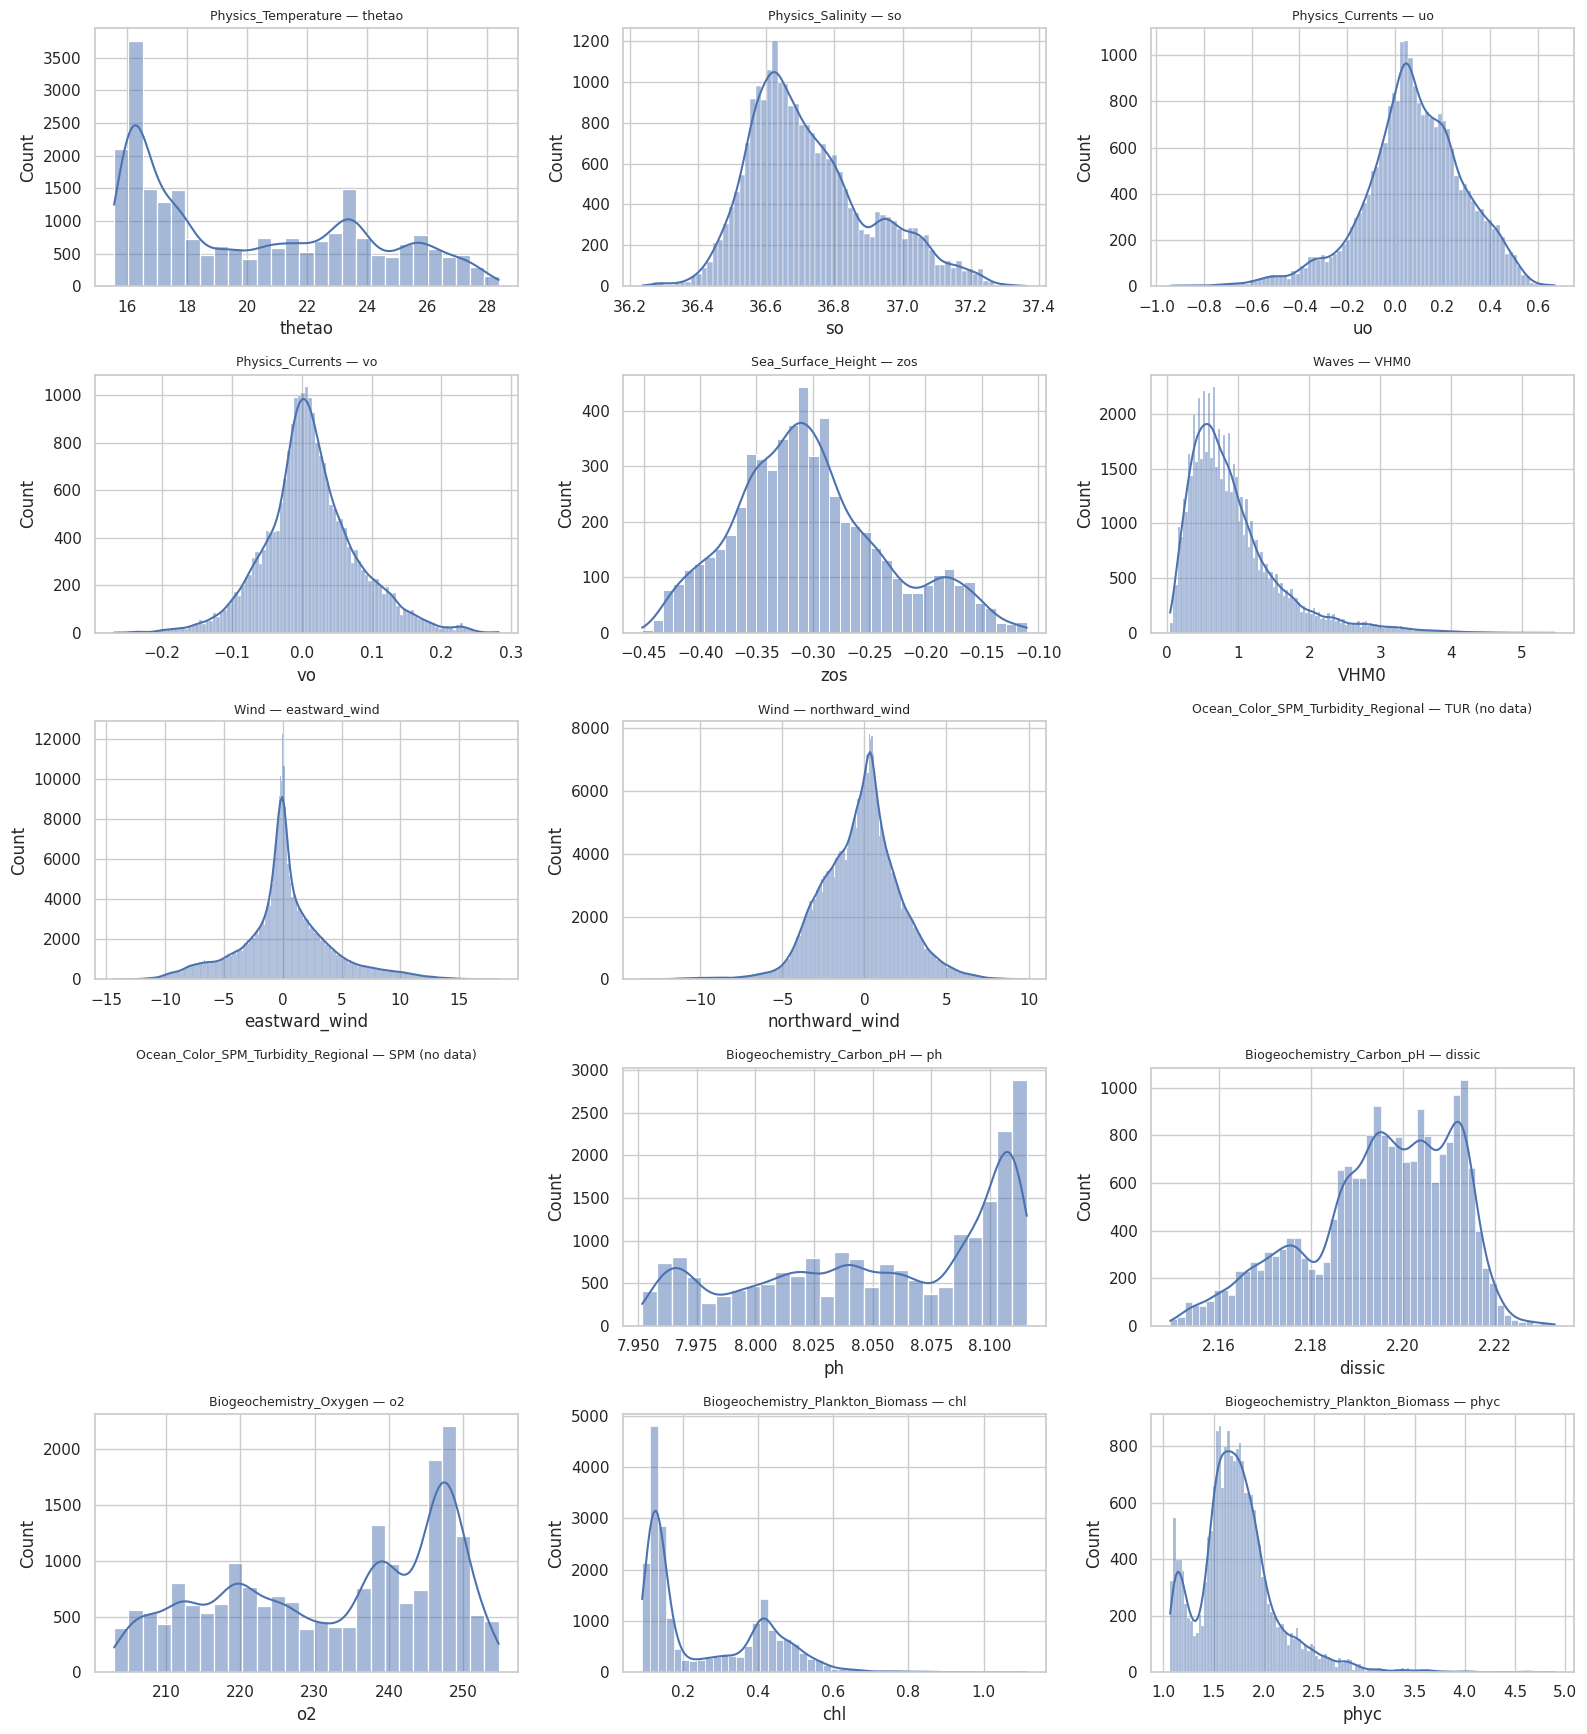

In [14]:
# flat (product, variable) list reused across the remaining sections
var_items = [(name, var) for name, meta in PRODUCTS.items() for var in meta["vars"]]
n_var_rows = -(-len(var_items) // n_cols)

# distributions per variable (raw, all grid points x all days)
fig, axes = plt.subplots(n_var_rows, n_cols, figsize=(16, 3.5 * n_var_rows))
axes = axes.ravel()
for ax, (name, var) in zip(axes, var_items):
    data = raw_data[name][var].dropna()
    if data.empty:
        ax.set_title(f"{name} — {var} (no data)", fontsize=9)
        ax.axis("off")
        continue
    sns.histplot(data, kde=True, ax=ax)
    ax.set_title(f"{name} — {var}", fontsize=9)
for ax in axes[len(var_items):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

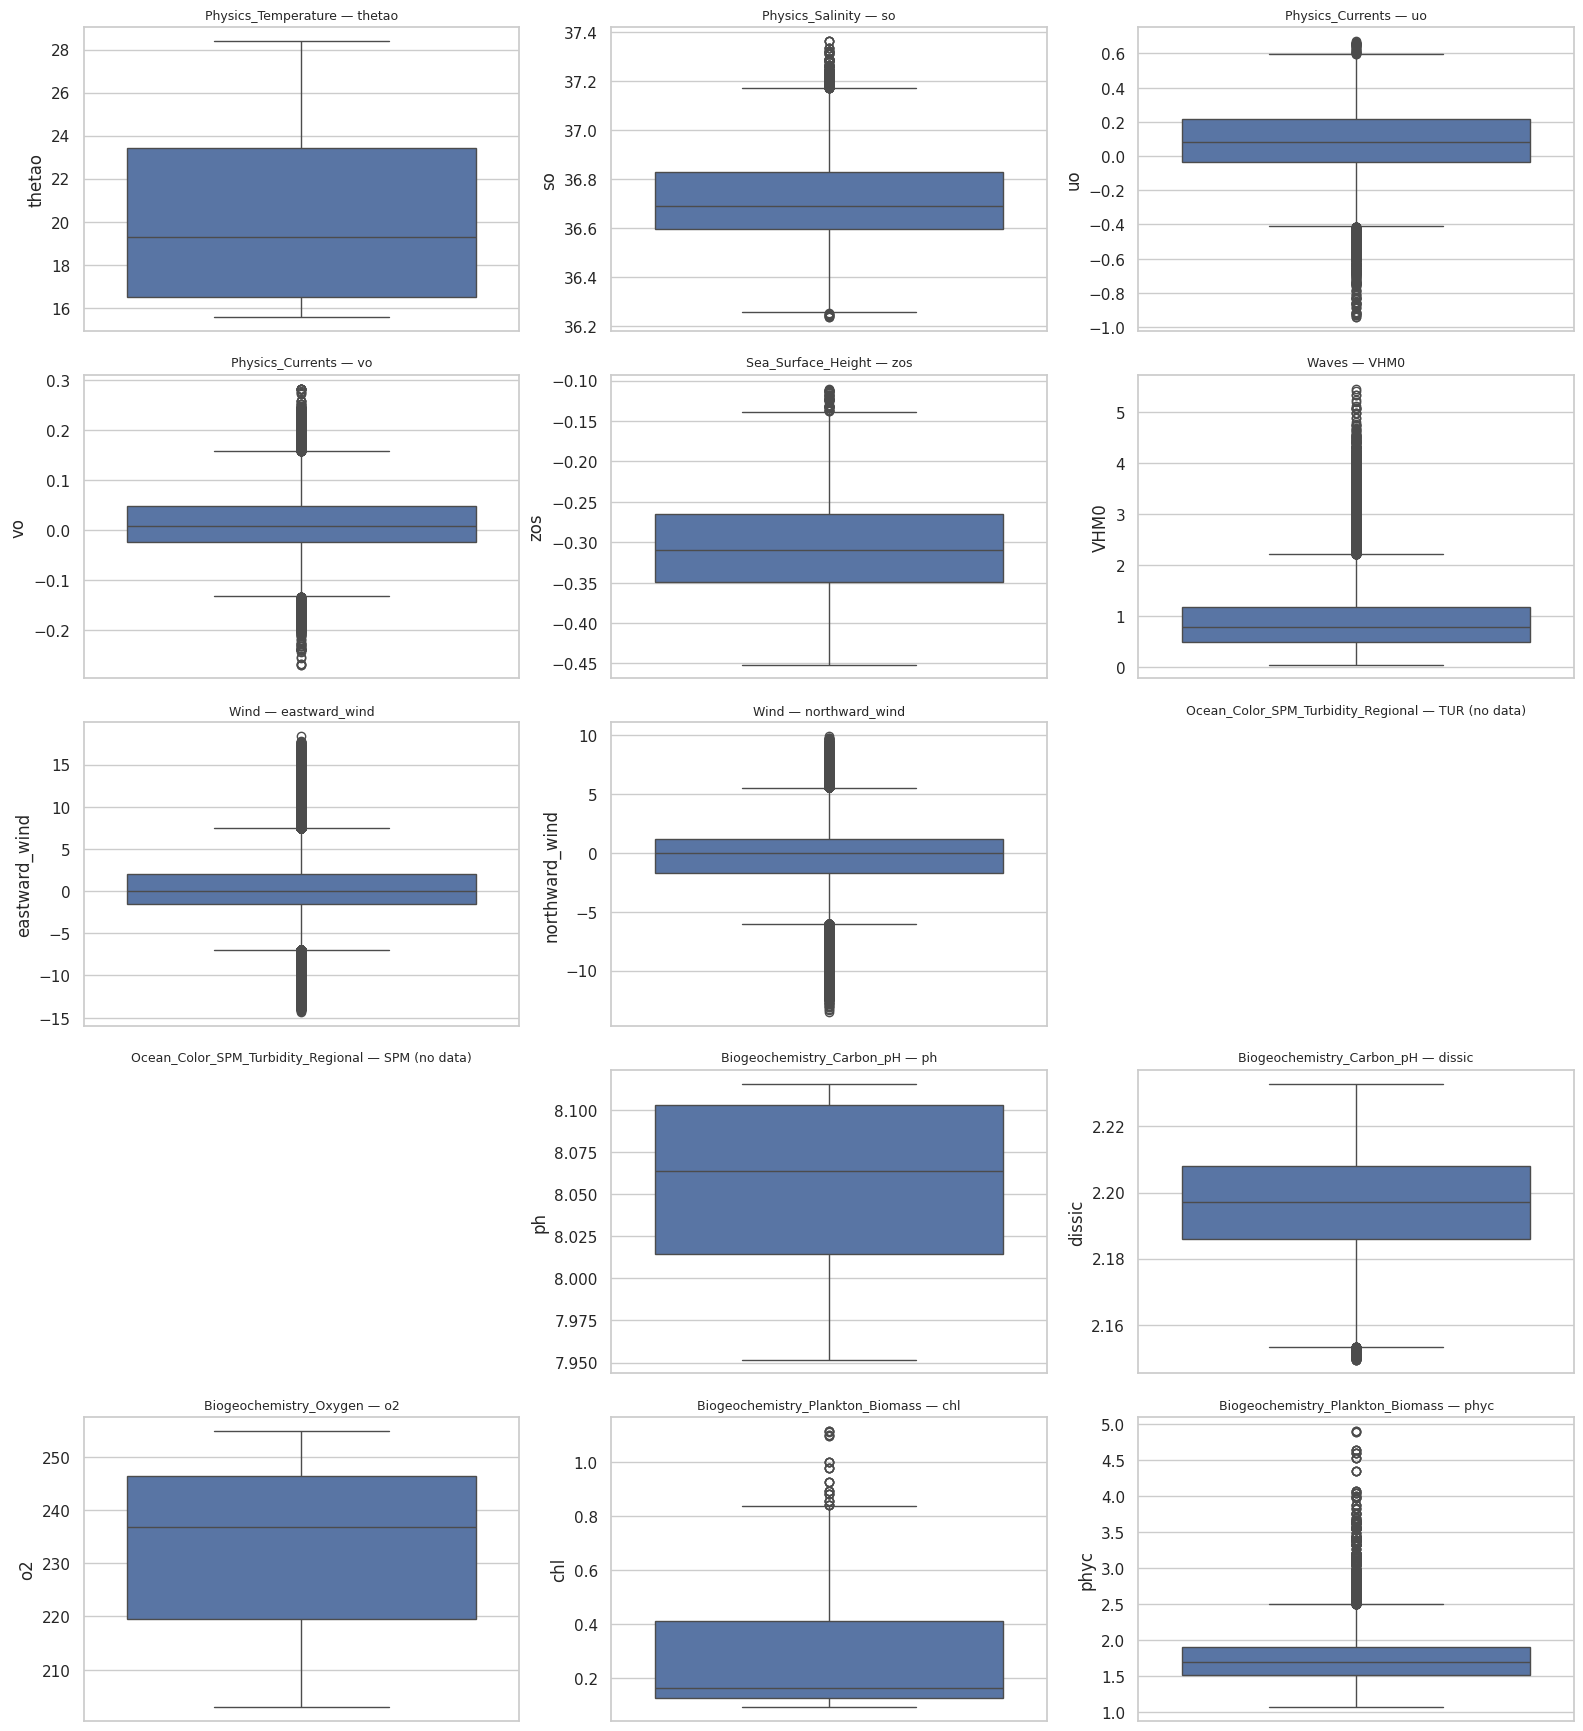

,product,variable,n_outliers_iqr,pct_outliers
0,Wind,eastward_wind,38654,9.732798
1,Waves,VHM0,3323,5.548691
2,Biogeochemistry_Plankton_Biomass,phyc,982,4.793050
3,Physics_Currents,vo,1070,4.526227
4,Physics_Currents,uo,620,2.622673
5,Wind,northward_wind,9277,2.335881
6,Physics_Salinity,so,395,1.670897
7,Sea_Surface_Height,zos,53,0.896785
8,Biogeochemistry_Carbon_pH,dissic,104,0.507614
9,Biogeochemistry_Plankton_Biomass,chl,36,0.175713


In [15]:
# boxplots + IQR-based outlier counts per variable
fig, axes = plt.subplots(n_var_rows, n_cols, figsize=(16, 3.5 * n_var_rows))
axes = axes.ravel()
outlier_rows = []
for ax, (name, var) in zip(axes, var_items):
    data = raw_data[name][var].dropna()
    if data.empty:
        ax.set_title(f"{name} — {var} (no data)", fontsize=9)
        ax.axis("off")
        continue
    sns.boxplot(y=data, ax=ax)
    ax.set_title(f"{name} — {var}", fontsize=9)
    q1, q3 = data.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = int(((data < lower) | (data > upper)).sum())
    outlier_rows.append(
        {
            "product": name,
            "variable": var,
            "n_outliers_iqr": n_outliers,
            "pct_outliers": 100 * n_outliers / len(data),
        }
    )
for ax in axes[len(var_items):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

pd.DataFrame(outlier_rows).sort_values("pct_outliers", ascending=False).reset_index(drop=True)

## 7. Cross-variable relationships

In [16]:
# one merged daily table (daily median per variable) to explore relationships across products
daily_frames = [daily_median(raw_data[name], var).rename(var) for name, var in var_items]
daily_merged = pd.concat(daily_frames, axis=1).sort_index()
daily_merged

,thetao,so,uo,vo,zos,VHM0,eastward_wind,northward_wind,TUR,SPM,ph,dissic,o2,chl,phyc
day,,,,,,,,,,,,,,,
2024-02-01,16.353396,36.652120,0.138686,-0.009550,-0.313697,0.235,-1.040,-0.525,NaN,NaN,8.108189,2.214199,247.381120,0.317618,1.768734
2024-02-02,16.318092,36.618892,0.037928,-0.030878,-0.309265,0.220,0.020,-0.495,NaN,NaN,8.107291,2.214459,247.081945,0.335391,1.764200
2024-02-03,16.277378,36.603872,-0.073381,0.004890,-0.329210,0.750,-1.785,-0.165,NaN,NaN,8.107795,2.214454,246.953825,0.358694,1.800876
2024-02-04,16.215035,36.596095,-0.058628,0.014279,-0.358368,0.240,-0.485,0.845,NaN,NaN,8.108138,2.214323,246.970970,0.386745,1.954889
2024-02-05,16.183976,36.577804,0.001320,0.008973,-0.349529,0.090,-0.350,1.165,NaN,NaN,8.108568,2.214544,247.121410,0.376118,2.102461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-24,16.211373,36.672154,0.276153,0.055273,-0.365230,0.490,0.310,0.220,NaN,NaN,8.110614,2.193639,253.295915,0.306416,1.951124
2025-02-25,16.218355,36.684237,0.309554,0.026673,-0.366516,0.590,2.635,0.855,NaN,NaN,8.110484,2.192443,253.068145,0.315243,1.917005
2025-02-26,16.220261,36.691410,0.275552,0.054506,-0.364633,1.330,0.640,-1.495,NaN,NaN,8.110917,2.192383,252.739975,0.318700,1.870441


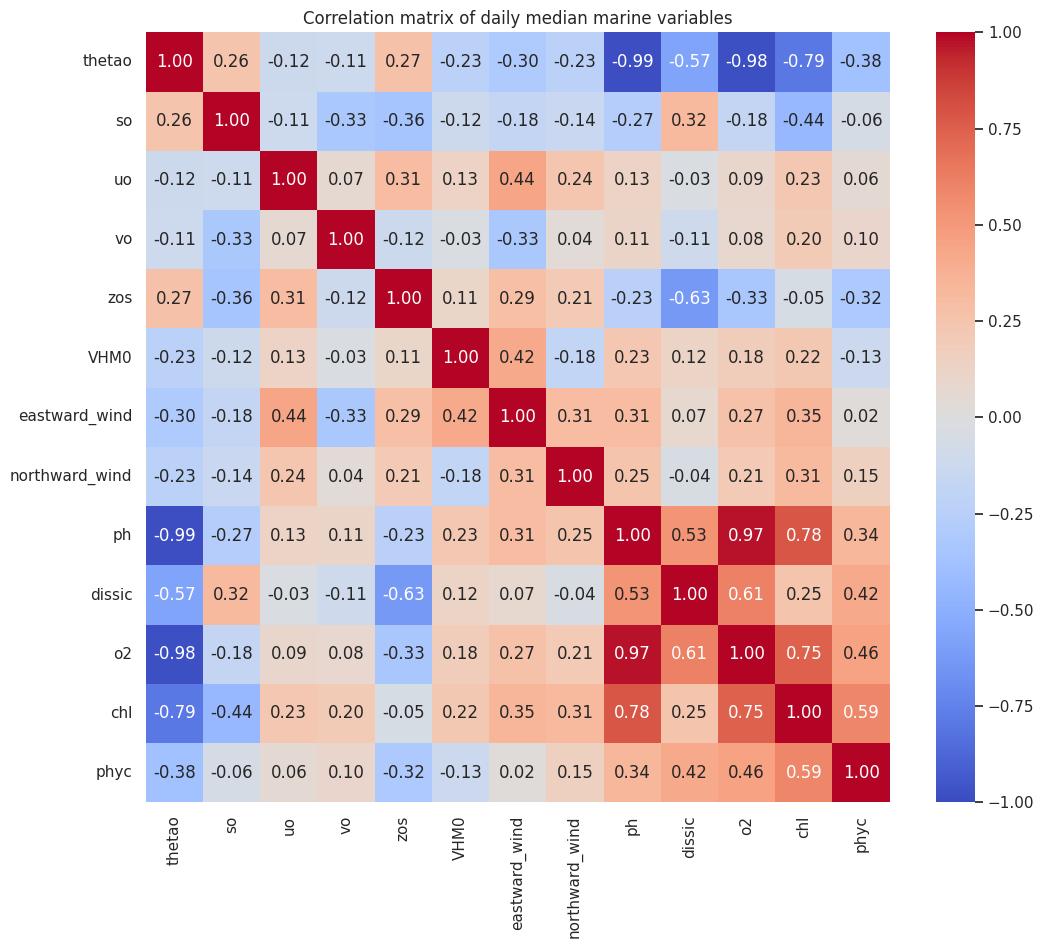

In [17]:
# correlation matrix across all variables that have at least some data (drops all-NaN TUR/SPM)
corr_cols = [c for c in daily_merged.columns if daily_merged[c].notna().any()]
corr_matrix = daily_merged[corr_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix of daily median marine variables")
plt.show()

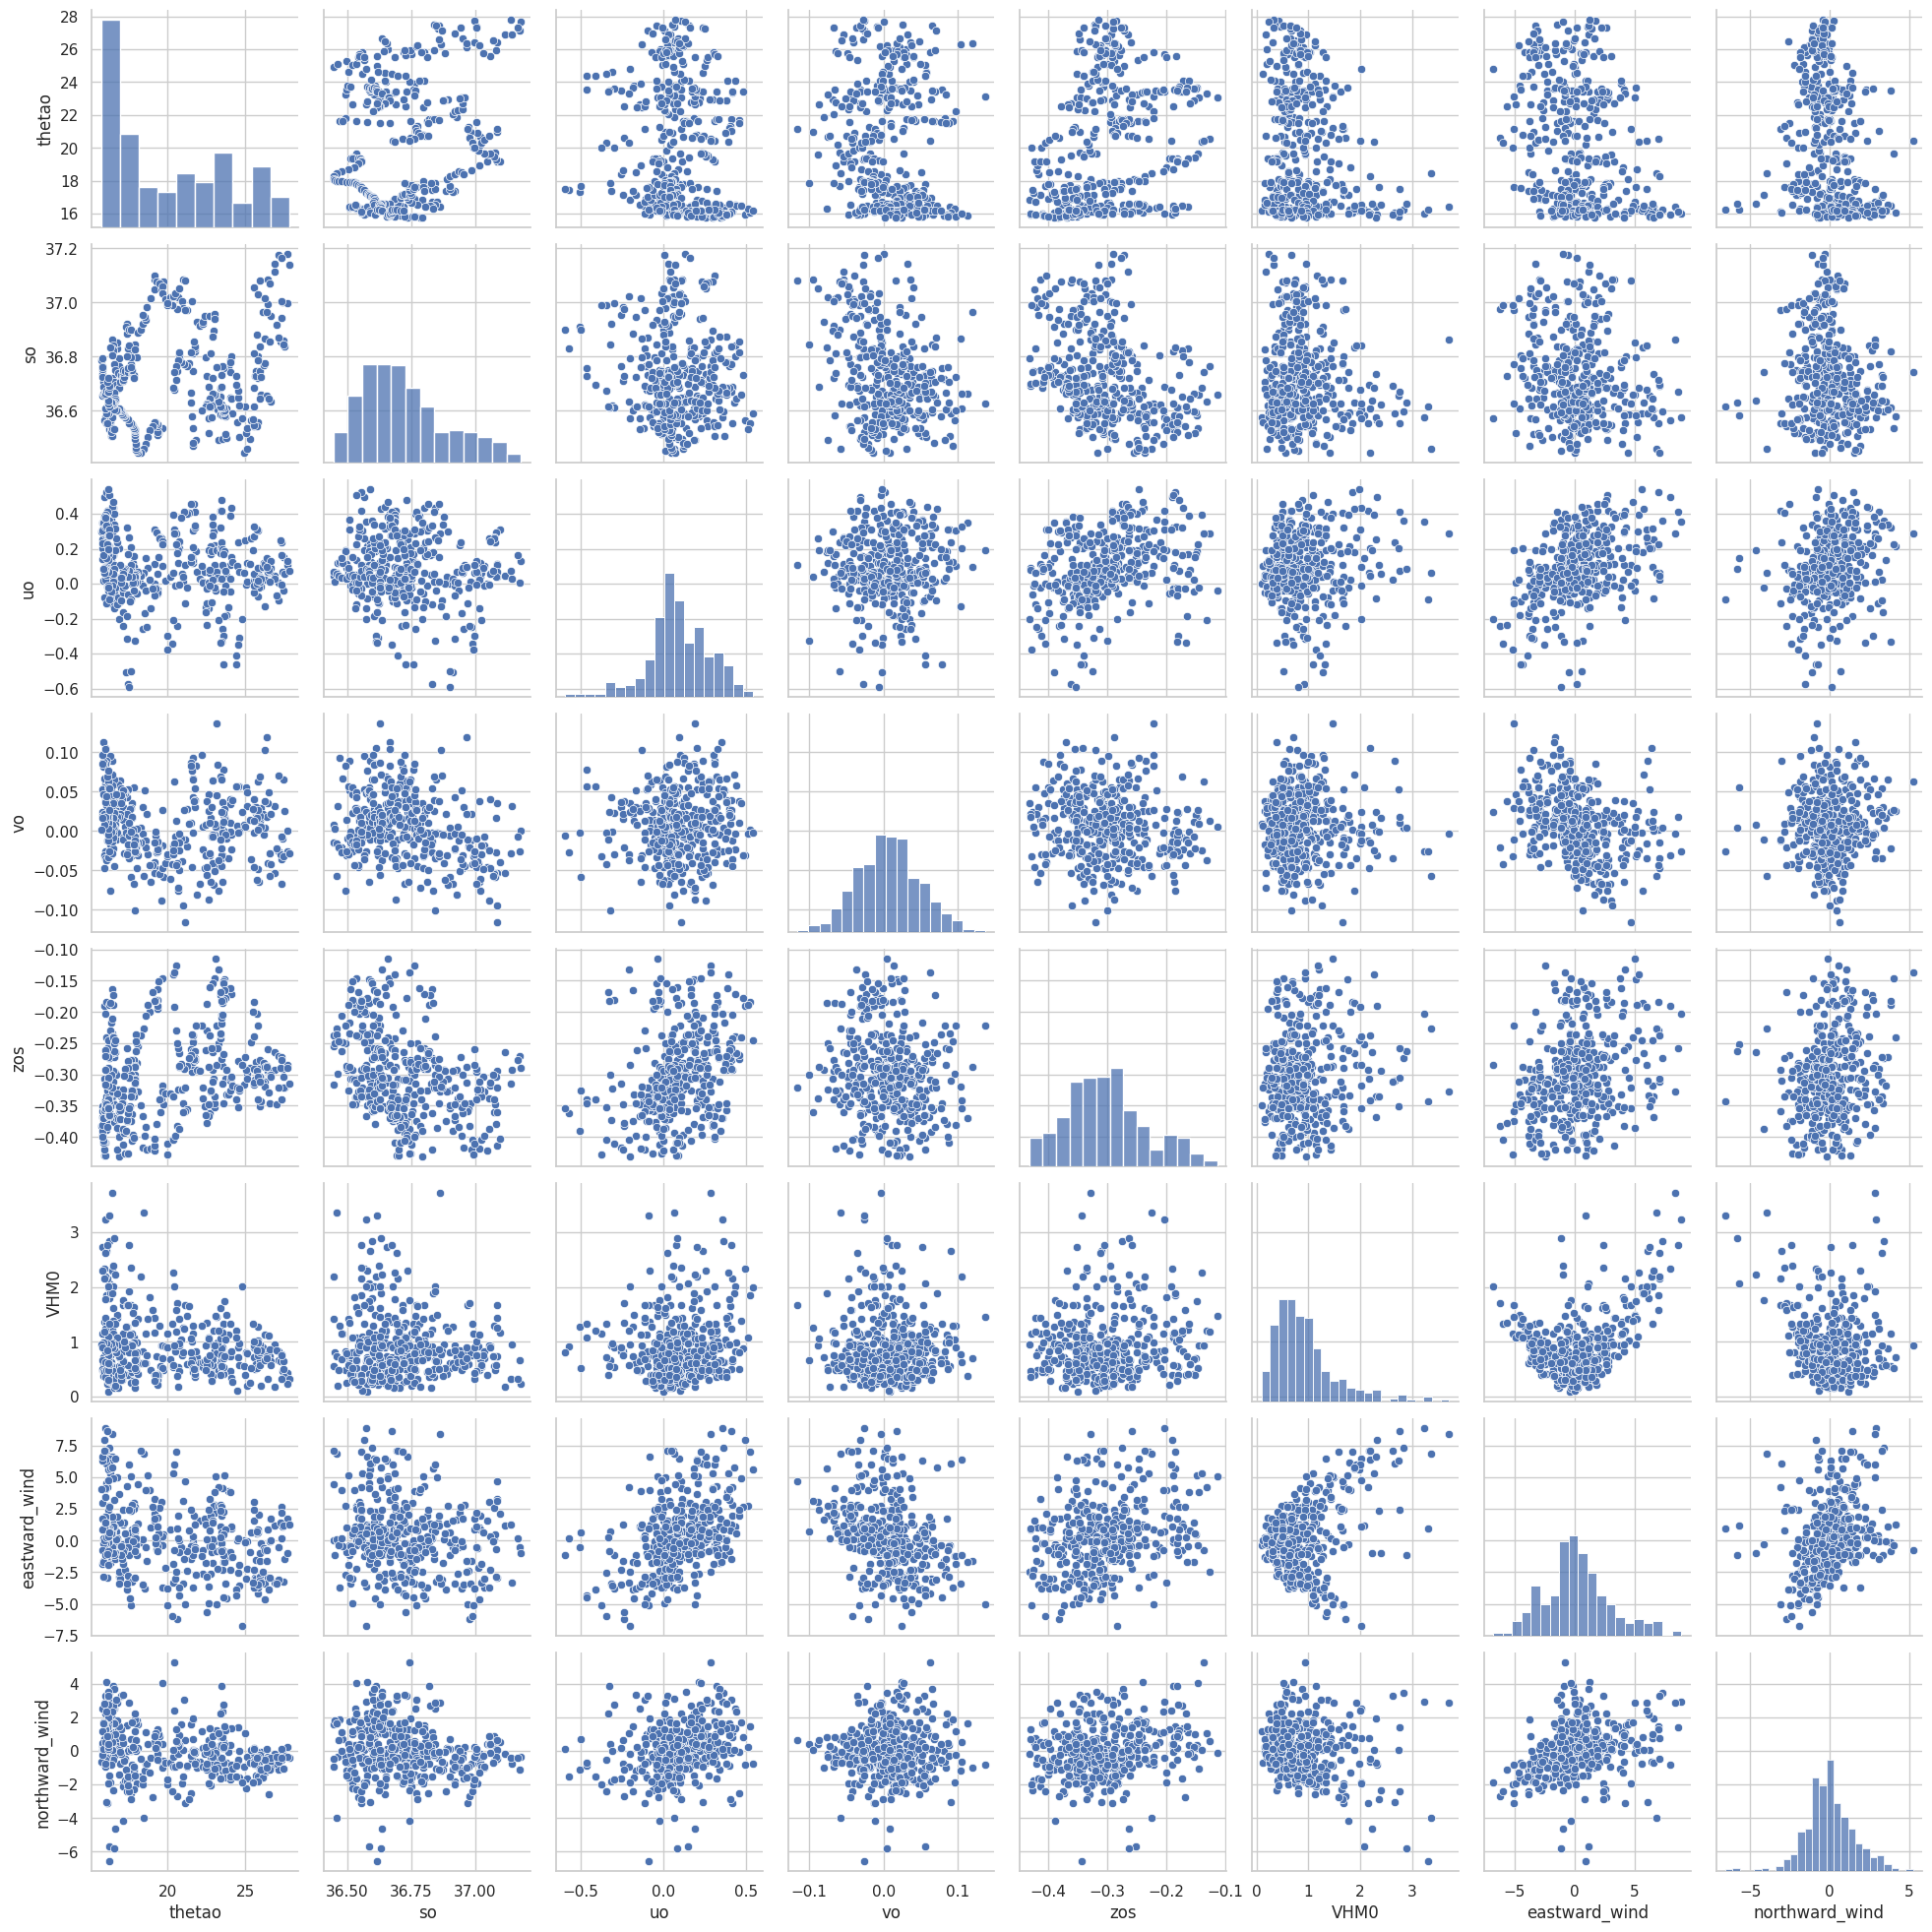

In [18]:
# pairplot of the core physical variables (temperature, salinity, currents, SSH, waves, wind)
core_vars = ["thetao", "so", "uo", "vo", "zos", "VHM0", "eastward_wind", "northward_wind"]
sns.pairplot(daily_merged[core_vars].dropna())
plt.show()